# Семинар 3. Прикладная линейная алгебра. Введение

*Внимание! Семинар содержит интерактивные демонстрации. На сайте они представлены в статическом виде. Для работы интерактивных элементов необходимо скачать страницу в формате ipynb и запустить ipynb-файл локально.*

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 2](https://m.youtube.com/watch?v=EK_LRstsQ04&t=1157s)  (начало темы),  [лекция 3](https://m.youtube.com/watch?v=mMWOaiq-sC0&t=38s) (продолжение).

Предполагается, что читатель знает
*   классификацию погрешностей вычислений,
*   основы линейной алгебры: матрицы и их свойства, собственные значения, методы решения систем линейных алгебраических уравнений и т.п.

# Введение

Прикладная линейная алгебра является, по-видимому, самой обширной и наиболее разработанной областью во всей вычислительной математике. Это объясняется **широкой распространённостью векторно-матричных вычислений**: с ними можно встретиться практически в любой области науки и техники. Хорошим примером служит бурно развивающийся в последние годы "искусственный интеллект". Алгоритмы и модели, которые принято относить к этой области анализа данных, во многом опираются на аппарат линейной алгебры. Показателен и тот факт, что все современные вычислительные программные пакеты обязательно включают модули, реализующие методы линейной алгебры. Существуют и специальные среды разработки, нацеленные именно на векторно-матричные вычисления (к ним относится, например, хорошо известный MATLAB, создатели которого руководствовались лозунгом: "Think vectorized!" — "Думай векторно!").

В рамках нашего курса методы прикладной линейной алгебры будут рассматриваться в осеннем и весеннем семестрах. В осеннем семестре целью изучения будет знакомство с различными методами, освоение основных идей и принципов, а также их применение для решения задач, **уже сформулированных** в виде задач линейной алгебры. В весеннем семестре те же задачи возникнут **как составляющие прикладных задач**, связанных с численным решением обыкновенных дифференциальных уравнений и уравнений в частных производных. В следующем семестре мы увидим, что решение многих начальных и краевых задач сводится к решению систем линейных алгебраических уравнений (далее — СЛАУ) большой размерности. Таковы, например, краевые задачи для уравнений Лапласа и Пуассона (**эллиптического типа**), возникающие, скажем, в расчётах прочности конструкций. Другой пример — начально-краевые задачи для уравнения теплопроводности (**параболического типа**), которые после применения той или иной разностной схемы (как правило, неявной) тоже приводят к СЛАУ специального вида. Потребность решать СЛАУ возникает и в других задачах — например, в теории интерполяции при построении **сплайнов** (об этом мы будем говорить на десятом семинаре).

К основным задачам прикладной линейной алгебры относятся
*   численное решение СЛАУ,
*   спектральные задачи (вычисление собственных значений и собственных векторов),
*   построение матричных разложений (QR-разложение, LU-разложение, сингулярное разложение и др.).

Эти задачи не являются независимыми. Так, многие эффективные методы решения СЛАУ основаны на предварительном разложении матрицы СЛАУ в произведение матриц специального вида. То же верно и для спектральных задач. Поэтому можно сказать, что в современной прикладной линейной алгебре первичной является последняя из перечисленных тем.

На семинарах вследствие ограниченности времени мы сконцентрируемся на первой задаче — численном решении СЛАУ. Чтобы тема матричных разложений не выпадала полностью из нашего рассмотрения, приведём простой пример практического применения одного из таких разложений. Этот пример ещё раз докажет нам, что методы прикладной линейной алгебры распространены очень широко. Идея примера заимствована из лекции А.В. Чикиткина: [ссылка](https://youtu.be/E4TL2oFmlyY?si=hNn7sLJQCTgVKh2Q&t=5951) (YouTube).

Рассмотрим задачу **сжатия изображения**. Пусть дано некоторое изображение, например, фотография лабораторного корпуса МФТИ. Загрузим её по ссылке, пользуясь средствами библиотеки ```imageio``` ([документация](https://imageio.readthedocs.io/en/latest/)), и отобразим как объект ```matplotlib.image``` ([документация](https://matplotlib.org/stable/api/image_api.html)):

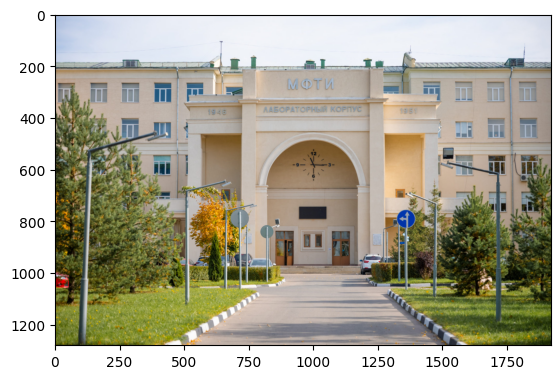

In [ ]:
import imageio.v2 as iio
import matplotlib.pyplot as plt

pic = iio.imread('https://phystech-union.org/wp-content/uploads/2020/10/dsc_8691.jpg', pilmode='RGB')
plt.imshow(pic)

Функция ```imread``` вернула нам трёхмерный массив с целочисленными 8-битными элементами:

In [ ]:
type(pic)

numpy.ndarray

In [ ]:
pic.shape

(1280, 1920, 3)

In [ ]:
pic.dtype

dtype('uint8')

Первые два измерения — это координаты пикселей изображения по высоте и ширине. Третье измерение отвечает за цветовой канал в RGB-кодировке: индекс "0" соответствует красному каналу, индекс "1" — зелёному, индекс "2" — синему. В этом можно убедиться, выделив, например, красную компоненту фотографии:

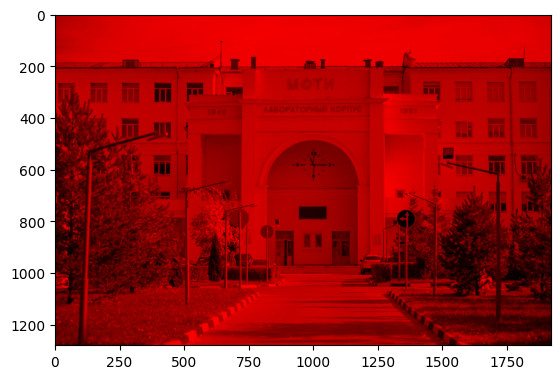

In [ ]:
import numpy as np

pic_red = np.zeros(pic.shape, dtype="uint8")
pic_red[:, :, 0] = pic[:, :, 0]
plt.imshow(pic_red)

Иначе говоря, мы имеем три двумерных массива (три матрицы), каждый из которых кодирует свой цветовой канал.

Размер (вес) исходного файла в байтах можно получить с помощью модуля ```request``` библиотеки ```urllib``` ([документация](https://docs.python.org/3/library/urllib.request.html)):

In [ ]:
from urllib import request

pic_file = request.urlopen('https://phystech-union.org/wp-content/uploads/2020/10/dsc_8691.jpg')
pic_file.length

462892

Как видим, фотография весит чуть больше 450 Кб (напомним, что $1$ Кб $= 2^{10}$ байт $= 1024$ байт, а не $10^3$ байт, хотя это и спорный вопрос). Наша цель — уменьшить этот вес. Для этого преобразуем матрицу каждого цветового канала с помощью сингулярного разложения.

Из линейной алгебры известно, что любую комплексную матрицу $\textbf{A}$ размера $m\times n$ можно представить в виде произведения трёх матриц:

$$\textbf{A}=\textbf{U}\boldsymbol{\Sigma}\textbf{V}^\dagger.$$

Здесь $\textbf{U}$ и $\textbf{V}$ — унитарные матрицы порядков $m$ и $n$ соотвественно, а $\boldsymbol{\Sigma}$ — матрица размера $m\times n$, все элементы которой нулевые, за исключением (быть может, не всех) элементов, расположенных на главной диагонали (мы не называем матрицу $\boldsymbol{\Sigma}$ диагональной, потому что этот термин обычно используют в случае квадратных матриц). Символ $\dagger$ обозначает эрмитово сопряжение. Указанное представление матрицы $\textbf{A}$ и называется **сингулярным разложением** (или SVD-разложением). Элементы $\sigma_i(\textbf{A})$, стоящие на главной диагонали матрицы $\boldsymbol{\Sigma}$, называются **сингулярными числами** матрицы $\textbf{A}$. Количество ненулевых сингулярных чисел матрицы $\textbf{A}$ совпадает с её рангом $r$.

Пусть для матрицы $\textbf{A}$ ранга $r$ получено сингулярное разложение. Выберем среди её ненулевых сингулярных чисел $q<r$ наибольших, а остальные положим равными нулю. Тогда из матрицы $\boldsymbol{\Sigma}$ получим матрицу $\boldsymbol{\Sigma}_q$. В сингулярном разложении матрицы $\textbf{A}$ заменим $\boldsymbol{\Sigma}$ на $\boldsymbol{\Sigma}_q$. В результате получим некоторую новую матрицу

$$\textbf{A}_q=\textbf{U}\boldsymbol{\Sigma}_q\textbf{V}^\dagger$$

ранга $q$. Процедура, которую мы описали, позволяет построить приближение матрицы $\textbf{A}$ матрицей $\textbf{A}_q$ меньшего ранга. Можно показать, что это приближение является наилучшим в том смысле, что его погрешность $||\textbf{A}-\textbf{A}_q||_\text{Fro}$ оказывается наименьшей из возможных при фиксированном ранге $q$ (через $||\cdot||_\text{Fro}$ обозначена норма Фробениуса — см. ниже). Последнее утверждение составляет содержание так называемой **теоремы Эккарта—Янга о низкоранговом приближении**.

Вернёмся к задаче сжатия изображения. С помощью функции ```svd``` модуля ```linalg``` библиотеки ```numpy``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)) получим сингулярные разложения для матриц трёх цветовых каналов. Поскольку в возвращаемом (одномерном) массиве ```sig``` сингулярные числа упорядочены по невозрастанию, для построения приближённых матриц меньшего ранга достаточно просто "обрезать" все сомножители сингулярного разложения до нужного ранга $q$. Затем по "обрезанным" сомножителям восстанавливается приближённая матрица заданного цветового канала (имеющая меньший ранг). Остаётся только привести все элементы итогового трёхмерного массива к 8-битным целым числам, чтобы его можно было интерпретировать как изображение. Приведение достигается за счёт использования функции ```clip``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)) и метода ```astype``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.astype.html)) библиотеки ```numpy```. Итак, имеем код:

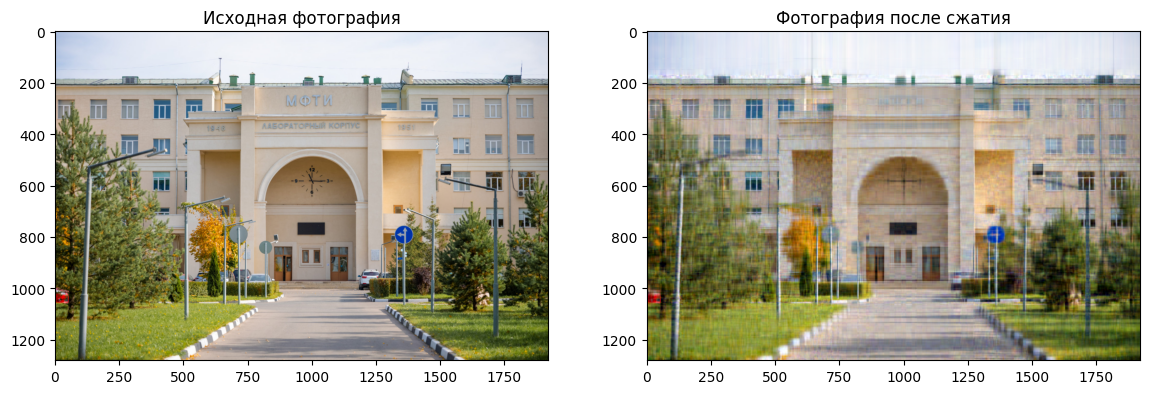

In [ ]:
def compress_image(q: int):
    comp_pic = np.zeros(shape=pic.shape, dtype=float)

    for i in range(0, 3):
        u, sig, v = np.linalg.svd(pic[:, :, i])

        # обрезка компонент сингулярного разложения
        u_q = u[:, :q]
        sig_q = sig[:q]
        v_q = v[:q, :]

        # собираем сжатый цветовой канал
        comp_pic[:, :, i] = u_q @ np.diag(sig_q) @ v_q

    # преобразуем элементы массива к 8-битным целым числам
    comp_pic = np.clip(np.rint(comp_pic), 0, 255)
    comp_pic = comp_pic.astype('uint8')

    # отрисовываем исходное изображение и результат сжатия
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    ax1.imshow(pic)
    ax2.imshow(comp_pic)

    ax1.set_title("Исходная фотография")
    ax2.set_title("Фотография после сжатия")

    return comp_pic

new_pic = compress_image(30) # степень сжатия можно регулировать

Можно проверить, что в результате сжатия размер файла (в байтах) уменьшился ([документация](https://docs.python.org/3/library/os.path.html) к функции ```getsize``` модуля ```path``` библиотеки ```os```):

In [ ]:
import os

comp_pic = iio.imwrite("compressed_picture.jpg", new_pic) # создаём новый файл формата jpg
os.path.getsize("compressed_picture.jpg") # получаем его размер

255278

# Нормы векторов и матриц

## Норма вектора

Пусть при решении СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ некоторым численным методом получено приближённое решение $\textbf{x}^*$. Как количественно оценить точность этого решения?

В одномерном случае (при решении одного уравнения) в качестве меры точности выступает абсолютная погрешность $\Delta(x^*)=|x-x^*|$. Чтобы ввести аналогичную конструкцию для оценки точности решения СЛАУ с большим количеством уравнений, необходимо обобщить понятие модуля (абсолютной величины) числа на многомерный случай. Это обобщение приводит нас к понятию нормы вектора.

**Определение 1.** Пусть $E$ — векторное (линейное) пространство. Функция $||\cdot||$, переводящая вектор $\textbf{x}\in E$ в *неотрицательное вещественное число*, обозначаемое $||\textbf{x}||$, называется *преднормой* (или *полунормой*), если для любых $\textbf{x},\textbf{y}\in E$ и $\lambda\in \mathbb{C}$ она удовлетворяет следующим двум условиям:
1. $||\lambda \textbf{x}||=|\lambda|\cdot||\textbf{x}||$,
2. $||\textbf{x}+\textbf{y}||\leq ||\textbf{x}||+||\textbf{y}||$ (неравенство треугольника).

Преднорма называется *нормой*, если она такова, что

3. из равенства $||\textbf{x}||=0$ следует, что $\textbf{x}=\textbf{0}$.

Векторное пространство, снабжённое преднормой, называется *преднормированным*, а снабжённое нормой — *нормированным пространством*.

Отметим, что, согласно первому условию, $||\textbf{0}||=||0\cdot\textbf{x}||=0\cdot ||\textbf{x}||=0$, т.е. верна импликация: $\textbf{x}=\textbf{0}\Rightarrow ||\textbf{x}||=0$. Поэтому третье условие из определения нормы иногда заменяют на такое: $||\textbf{x}||=0\Leftrightarrow\textbf{x}=\textbf{0}$.

Понятие нормы принадлежит к числу центральных понятий функционального анализа, в котором, как правило, рассматривают комплексные векторные пространства. Мы почти всегда будем считать, что $E=\mathbb{R}^n$. Поскольку это действительное пространство, константа $\lambda$ из определения 1 тоже действительна.

Мы также предполагаем, что рассматриваемое векторное пространство является **евклидовым** (поэтому в определении 1 и использовано обозначение $E$), т.е. в нём введено **скалярное произведение**. Вообще говоря, скалярное произведение $(\textbf{x},\textbf{y})$ векторов $\textbf{x}$ и $\textbf{y}$ может быть задано не единственным способом. Мы полагаем (в общем случае комплексного пространства)

$$(\textbf{x},\textbf{y})=\textbf{y}^\dagger\textbf{x}=\sum\limits_{i=1}^nx_iy_i^*,$$

а в наиболее важном для нас случае $E=\mathbb{R}^n$

$$(\textbf{x},\textbf{y})=\textbf{y}^\text{T}\textbf{x}=\sum\limits_{i=1}^nx_iy_i.$$

Такое скалярное произведение иногда называется **стандартным**. Здесь и далее символ $*$ обозначает комплексное сопряжение, а символ $\dagger$ — эрмитово сопряжение. Напомним, что $(\cdot)^\dagger=\big((\cdot)^\text{T}\big)^*=\big((\cdot)^*\big)^\text{T}$.

## Примеры векторных норм

В пространстве $\mathbb{R}^n$ можно ввести бесконечно много различных векторных норм. Часто используются так называемые **$p$-нормы** (или гёльдеровы нормы, или $l_p$-нормы), определяемые как

$$||\textbf{x}||_p=\bigg(\sum\limits_{i=1}^n|x_i|^p\bigg)^{1/p},\quad p\in\mathbb{N}.$$

К классу $p$-норм относят также норму

$$||\textbf{x}||_\infty=\lim_{p\to\infty}\bigg(\sum\limits_{i=1}^n|x_i|^p\bigg)^{1/p}=\max_i|x_i|.$$

**Упражнение.** Показать справедливость последнего равенства, т.е. вычислить входящий в него предел.

Нетрудно убедиться в том, что выписанные функции векторов действительно являются нормами. Очевидно, что их область значения есть $\mathbb{R}_+$. Очевидно также, что первая и третья аксиомы нормы выполняются. Справедливость неравенства треугольника очевидна для нормы $||\cdot||_\infty$. Для произвольной $p$-нормы оно доказывается несколько сложнее и, вообще говоря, является следствием **неравенства Гёльдера** (за подробностями отсылаем к курсам функционального анализа).

В вычислительной математике наиболее часто используются три векторные нормы, принадлежащие к классу $p$-норм:

* **кубическая норма** ($p=\infty$):

$$||\textbf{x}||_1=\max_i|x_i|,$$

* **октаэдрическая** ("манхэттенская") **норма** ($p=1$):

$$||\textbf{x}||_2=\sum\limits_{i=1}^n|x_i|,$$

* **евклидова** (сферическая) **норма** ($p=2$):

$$||\textbf{x}||_3=\sqrt{\sum\limits_{i=1}^n|x_i|^2}=\sqrt{(\textbf{x},\textbf{x})}.$$

Здесь и далее мы используем для трёх перечисленных норм обозначения $||\cdot||_1$, $||\cdot||_2$ и $||\cdot||_3$, ставшие традиционными для научной школы МФТИ.

Выясним смысл названий "кубическая", "октаэдрическая" и "сферическая", изобразив в каждом из трёх случаев множество $\mathbb{T}=\{\textbf{x}\in\mathbb{R}^n: ||\textbf{x}||=1\}$ (**единичную сферу**) при $n=2$. Поскольку это множество точек не является графиком функции (если рассматривать всю плоскость $\mathbb{R}^2$), создадим массив из случайных точек плоскости и отфильтруем его, выбрав точки, составляющие контур единичной сферы (ширину контура регулируем с помощью параметра ```eps```). Нормы будем вычислять с помощью функции ```norm``` модуля ```linalg``` библиотеки ```numpy``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html#numpy-linalg-norm)).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, IntSlider

# ползунок для интерактивного графика (виджета)
p_w = IntSlider(min=1, max=100, value=1)

def graph_norm(p: int):
    points = np.random.randn(100000, 2)

    eps = 10**(-2) # отвечает за ширину контура
    mask = (np.linalg.norm(points, ord=p, axis=1) <= 1 + eps) & (np.linalg.norm(points, ord=p, axis=1) >= 1 - eps)
    filtered_points = points[mask]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(filtered_points[:, 0], filtered_points[:, 1], 0.7, color='k')

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

    plt.title("Единичные сферы в различных $p$-нормах")
    plt.show()

interact(graph_norm, p=p_w);

interactive(children=(IntSlider(value=1, description='p', min=1), Output()), _dom_classes=('widget-interact',)…

Как видим, при $p=1$ (октаэдрическая норма) единичная сфера есть ромб, а при $p=2$ (сферическая норма) — окружность. Увеличивая $p$, замечаем, что множество точек $\mathbb{T}$ стремится к квадрату, поэтому очевидно, что при $p=\infty$ (кубическая норма) в качестве единичной сферы мы имеем квадрат (это можно проверить, положив в программе ```ord=np.inf```).

Ясно, что при $n=3$ единичные сферы для первой, второй и третьей норм будут представлять собой куб, октаэдр и "обычную" сферу соответственно. Отсюда и следуют упомянутые выше названия.

Второе название октаэдрической нормы — "манхэттенская" — связано с уличной планировкой острова Манхэттен в Нью-Йорке. В этом районе города улицы образуют прямоугольную сетку, и кратчайший путь между двумя точками на этой сетке измеряется суммой расстояний по горизонтали и вертикали.

![image](pic/sem03_manh.jpg)

*На фото: прямоугольная сетка улиц в боро Манхэттен (Нью-Йорк, США). [Ссылка](https://www.fathomaway.com/daily-overview-benjamin-grant/)*

В лекционном курсе понятие нормы вектора используется для доказательства ряда теоретических положений. В связи с этим возникает вопрос: не будут ли изменяться выводы теории (и, соответственно, их практические следствия) при использовании различных норм?

Оказывается, что **в конечномерных пространствах** все векторные нормы в некотором смысле одинаковы, так что безразлично, какая именно норма используется при построении теории. Более строго, справедлива следующая теорема (мы сформулируем её для $\mathbb{R}^n$).

**Теорема 1 (об эквивалентности норм).** Если $||\cdot||_1$ и $||\cdot||_2$ — две произвольные нормы на $\mathbb{R}^n$, то существуют действительные константы $C_1, C_2>0$ такие, что для любого вектора $\textbf{x}\in\mathbb{R}^n$ справедливы *соотношения эквивалентности*

$$C_1||\textbf{x}||_1\leq||\textbf{x}||_2\leq C_2||\textbf{x}||_1.$$

Приведём соотношения эквивалентности для трёх основных норм в $\mathbb{R}^n$:

$$\begin{align}
  n^{-1}||\textbf{x}||_2\leq ||&\textbf{x}||_1\leq ||\textbf{x}||_2,\\[0.2cm]
  ||\textbf{x}||_1\leq ||&\textbf{x}||_2\leq n||\textbf{x}||_1,\\[0.2cm]
  n^{-1/2}||\textbf{x}||_2\leq ||&\textbf{x}||_3\leq ||\textbf{x}||_2,\\[0.2cm]
  ||\textbf{x}||_1\leq ||&\textbf{x}||_3\leq n^{1/2}||\textbf{x}||_1.\\[0.2cm]
\end{align}$$

**Упражнение.** Получить перечисленные соотношения эквивалентности.

Из теоремы 1 следует, что если в одной норме установлены, например, некоторые оценки, то эти оценки останутся справедливыми и в другой норме, быть может, с точностью до некоторых констант, не зависящих от рассматриваемых векторов. Предельные же результаты при переходе к другой норме и вовсе не меняются.

В дальнейшем, формулируя теоремы из лекционного курса, мы не будем конкретизировать используемую норму, подразумевая, что все нормы эквивалентны в смысле теоремы 1. При решении задач и разборе примеров будем пользоваться наиболее удобными в рассматриваемых случаях нормами.

## Норма матрицы

Для дальнейшего, наряду с понятием нормы вектора, нам понадобится понятие **нормы матрицы**.

Из курса линейной алгебры известно, что множество матриц $\text{Mat}_{n\times m}(\mathbb{F})$ над полем $\mathbb{F}$ является векторным пространством. Кроме того, известно, что существует изоморфизм $\text{Mat}_{n\times m}(\mathbb{F})\cong\mathbb{F}^{n\times m}$. Поэтому норму матрицы $\text{Mat}_{n\times m}(\mathbb{F})$ можно ввести, выбрав некоторую векторную норму в пространстве $\mathbb{F}^{n\times m}$. Легко видеть, что такой подход эквивалентен аксиоматическому определению нормы матрицы. Мы сформулируем соответствующее определение (аналогичное определению 1) для случая $\mathbb{F}=\mathbb{R}$.

**Определение 2.** Пусть $\text{Mat}_{n\times m}(\mathbb{R})$ — векторное пространство матриц размера $n\times m$ с вещественными элементами. Функция $||\cdot||$, переводящая матрицу $\textbf{A}\in \text{Mat}_{n\times m}(\mathbb{R})$ в *неотрицательное вещественное число*, обозначаемое $||\textbf{A}||$, называется *аддитивной (или обобщённой) матричной нормой*, если для любых $\textbf{A},\textbf{B}\in \text{Mat}_{n\times m}(\mathbb{R})$ и $\alpha\in \mathbb{R}$ она удовлетворяет следующим аксиомам:
1. $||\alpha \textbf{A}||=|\alpha|\cdot||\textbf{A}||$,
2. $||\textbf{A}+\textbf{B}||\leq ||\textbf{A}||+||\textbf{B}||$,
3. $||\textbf{A}||=0\Leftrightarrow \textbf{A}=\textbf{0}$.

Если, кроме того, для матриц $\textbf{C}\in \text{Mat}_{n\times m}(\mathbb{R})$ и $\textbf{D}\in \text{Mat}_{m\times k}(\mathbb{R})$ выполнено соотношение

4. $||\textbf{C}\textbf{D}||\leq ||\textbf{C}||\cdot||\textbf{D}||$

при одинаковом выборе норм в пространствах $\text{Mat}_{n\times m}(\mathbb{R})$, $\text{Mat}_{m\times k}(\mathbb{R})$ и $\text{Mat}_{n\times k}(\mathbb{R})$, то такая матричная норма называется *мультипликативной* (или самосогласованной).



Оказывается, что всякую аддитивную матричную норму можно превратить в мультипликативную домножением на некоторую положительную константу (достаточно большую). Поэтому **обычно рассматривают только мультипликативные нормы**, называя их просто нормами.

В дальнейшем нас будет интересовать преимущественно случай квадратных матриц порядка $n$.

Пусть, например, пространство $\mathbb{R}^{n\times n}$ снабжено евклидовой нормой вектора. При этом в пространстве $\text{Mat}_{n\times n}(\mathbb{R})$ автоматически вводится матричная норма

$$||\textbf{A}||_\text{Fro}=\sqrt{\sum\limits_{i,j=1}^n |a_{ij}|^2}.$$

Здесь $a_{ij}$ — элементы матрицы $\textbf{A}$. Норма $||\cdot||_\text{Fro}$ называется **нормой Фробениуса** (реже — сферической нормой). Можно показать, что она является мультипликативной.

Аналогично, вводя в пространстве $\mathbb{R}^{n\times n}$ кубическую норму вектора, получаем (аддитивную) матричную норму

$$||\textbf{A}||_\text{max}=\max_{i,j}|a_{ij}|,$$

называемую **max-нормой** матрицы $\textbf{A}$. Она не является мультипликативной (но может быть сделана таковой).

**Упражнение.** Проверить, что домножение max-нормы матрицы на размерность пространства $\mathbb{R}^n$ делает её мультипликативной. Иначе говоря, проверить, что матричная норма $||\cdot||=n\cdot||\cdot||_\text{max}$ мультипликативна.

Для задач вычислительной математики важен особый класс матричных норм, включающий нормы, **согласованные с векторными нормами**.

**Определение 3.** Пусть в линейных пространствах $\text{Mat}_{n\times n}(\mathbb{R})$ и $\mathbb{R}^n$ введены матричная и векторная нормы соответственно. Говорят, что *нормы матрицы и вектора согласованы*, если для любых $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{R})$ и $\textbf{x}\in\mathbb{R}^n$ справедливо неравенство

$$||\textbf{A}\textbf{x}||\leq ||\textbf{A}||\cdot||\textbf{x}||.$$

До сих пор, обсуждая понятие матричной нормы, мы рассматривали матрицы как таблицы с числами (элементами некоторого поля, в частности, $\mathbb{R}$). Можно, однако, вести рассмотрение с иной — **операторной** — **точки зрения** и считать первичным объектом линейный оператор $A:\mathbb{R}^n\to\mathbb{R}^n$, который при выборе некоторого базиса в $\mathbb{R}^n$ задаётся матрицей $\textbf{A}$. Поскольку в качестве векторного пространства мы будем рассматривать только $\mathbb{R}^n$ со стандартным базисом ($n$ векторов $\textbf{e}^{(k)}$ таких, что $\textbf{e}^{(k)}_i=\delta_{ik}$), понятия линейного оператора и его матрицы для нас будут тождественными. Такое отождествление некорректно с точки зрения функционального анализа, так как, **вообще говоря, линейный оператор и матрица — это не одно и то же**. Но с чисто практической, вычислительной точки зрения термины "матрица" и "линейный оператор" можно считать синонимичными.

Сказанное позволяет ввести понятие **подчинённой матричной нормы**. В функциональном анализе соответствующая конструкция обычно возникает как норма ограниченного линейного оператора.

**Определение 4.** Пусть пространство $\mathbb{R}^n$ снабжено некоторой векторной нормой. Функция

$$||\textbf{A}||=\sup_{\textbf{x}\neq\textbf{0}}\frac{||\textbf{A}\textbf{x}||}{||\textbf{x}||},$$

определённая для произвольной матрицы $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{R})$, называется *подчинённой (или операторной, или индуцированной) матричной нормой*.

Легко видеть, что **подчинённая норма**, во-первых, действительно является нормой (причём мультипликативной), а во-вторых, **оказывается согласованной с определяющей её векторной нормой**. Отметим, что **не всякая матричная норма является подчинённой**. Например, упоминавшиеся выше норма Фробениуса и норма $||\cdot||=n\cdot||\cdot||_\text{max}$ не подчинены никаким векторным нормам.

**Упражнение.** Показать, что

$$||\textbf{A}||^{-1}=\inf_{\textbf{x}\neq\textbf{0}}\frac{||\textbf{A}^{-1}\textbf{x}||}{||\textbf{x}||}.$$

Далее мы будем пользоваться почти исключительно подчинёнными матричными нормами — теми, которые индуцируются тремя основными векторными нормами. Выпишем соответствующие нормы:

*   Кубической норме вектора $||\cdot||_1$ подчинена матричная норма

  $$||\textbf{A}||_\text{I}=\max_i\sum\limits_{j=1}^n|a_{ij}|,$$

  равная наибольшей из **построчных** сумм **модулей** элементов матрицы.

*   Октаэдрической норме вектора $||\cdot||_2$ подчинена матричная норма

  $$||\textbf{A}||_\text{II}=\max_j\sum\limits_{i=1}^n|a_{ij}|,$$

  равная наибольшей из **постолбцовых** сумм **модулей** элементов матрицы.

*   Евклидовой норме вектора $||\cdot||_3$ подчинена матричная норма (называемая иногда **спектральной нормой**)

  $$||\textbf{A}||_\text{III}=\sqrt{\max_i\big[\lambda_i(\textbf{A}^\dagger \textbf{A})\big]},$$

  где через $\lambda(\textbf{A}^\dagger \textbf{A})$ обозначено собственное значение (эрмитовой) матрицы $\textbf{A}^\dagger \textbf{A}$. Напомним, что все собственные значения эрмитовой матрицы порядка $n$ вещественны, причём их ровно $n$, так как собственные векторы образуют ортогональный базис. В частном случае вещественной матрицы

  $$||\textbf{A}||_\text{III}=\sqrt{\max_i\big[\lambda_i(\textbf{A}^\text{T} \textbf{A})\big]},$$

  а если матрица $\textbf{A}$ симметрична ($\textbf{A}=\textbf{A}^\text{T}$), то

  $$||\textbf{A}||_\text{III}=\max_i\big|\lambda_i(\textbf{A})\big|,$$

  поскольку $\lambda(\textbf{A}^2)=\lambda^2(\textbf{A})$.



**Упражнение.** Докажите, что норма $||\cdot||_\text{III}$ не превосходит любой (операторной) матричной нормы.

*Указание.* Начните с доказательства двух утверждений: что модуль любого собственного значения матрицы не превосходит любой её нормы и что эрмитово сопряжение не меняет операторную норму матрицы.

Вычисление матричных норм реализовано в библиотеке ```numpy``` в виде той же функции ```norm``` модуля ```linalg``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html#numpy-linalg-norm)), которую мы использовали выше, когда строили единичные сферы в различных нормах. Удобно, что при заданном параметре $p$ в случае вектора (одномерного массива) функция возвращает соответствующую $p$-норму, а в случае матрицы (двумерного массива) — подчинённую этой векторной норме матричную норму (матричная норма будет вычислена только при $p=1,\,2$). Для двумерных массивов доступно также вычисление нормы Фробениуса (```ord='fro'```) и так называемой **ядерной** (или следовой) **нормы** (```ord='nuc'```). Последняя определяется как сумма сингулярных чисел матрицы (и совпадает со следом эрмитовой матрицы $\textbf{A}^\dagger \textbf{A}$, что и объясняет её второе название):

$$||\textbf{A}||_\text{nuc}=\sum\limits_i\sigma_i(\textbf{A})=\text{Tr}(\textbf{A}^\dagger \textbf{A}).$$

Для разнообразия приведём примеры с комплексной матрицей:

In [ ]:
import numpy as np

A = [ [ 2 + 1j, -3     , 2 + 1j],
      [-1 + 2j, -2 - 3j, 1 - 2j],
      [ 2 + 1j, -3 + 1j, 0     ] ]

norm_I = float(np.linalg.norm(A, ord=np.inf))
norm_I

8.07768723046357

In [ ]:
norm_II = float(np.linalg.norm(A, ord=1))
norm_II

9.76782893563237

In [ ]:
norm_III = float(np.linalg.norm(A, ord=2))
norm_III

6.835768145099583

In [ ]:
norm_Fro = float(np.linalg.norm(A, ord='fro'))
norm_Fro

7.54983443527075

In [ ]:
norm_nuc = float(np.linalg.norm(A, ord='nuc'))
norm_nuc

10.040806969582341

Выше мы уже отметили, что **подчинённая матричная норма согласована с той векторной нормой, которой она подчинена**. В частности, для рассматриваемых трёх пар векторных и матричных норм справедливы неравенства:

$$\begin{align}
  ||\textbf{A}\textbf{x}||_1&\leq ||\textbf{A}||_\text{I}\cdot||\textbf{x}||_1,\\
  ||\textbf{A}\textbf{x}||_2&\leq ||\textbf{A}||_\text{II}\cdot||\textbf{x}||_2,\\
  ||\textbf{A}\textbf{x}||_3&\leq ||\textbf{A}||_\text{III}\cdot||\textbf{x}||_3.
\end{align}$$

Поставим вопрос о том, на каких векторах $\textbf{x}_1$, $\textbf{x}_2$ и $\textbf{x}_3$ достигаются соответствующие равенства. Это понадобится нам в дальнейшем.

* Оказывается, что в случае кубической нормы вектора и индуцированной ею матричной нормы равенство достигается на векторе

  $$\textbf{x}_1=(\text{sign }a_{k1}, \text{sign }a_{k2}, ..., \text{sign }a_{kn})^\text{T}.$$

  Здесь $k$ — номер **строки** матрицы $\textbf{A}$, доставляющей максимальную построчную сумму модулей элементов.

* В случае октаэдрической нормы

  $$\textbf{x}_2\in\mathbb{R}^n:\quad (\textbf{x}_2)_i=\delta_{ik},\quad 1\leq i,k\leq n.$$

  Здесь $k$ — номер **столбца** матрицы $\textbf{A}$, доставляющего максимальную постолбцовую сумму модулей элементов.

* Наконец, в случае евклидовой нормы

  $$\textbf{x}_3=\textbf{h},$$

  где $\textbf{h}$ — собственный вектор матрицы $\textbf{A}$, отвечающий наибольшему по модулю собственному значению.

## Задача 1

Является ли функция $f_i(\textbf{x})$ нормой вектора $\textbf{x}\in\mathbb{R}^2$? Если является, найти подчинённую матричную норму.
1. $f_1(\textbf{x})=\min\big(7|x_1|+3|x_2|, 3|x_1|+7|x_2|\big)$,

2. $f_2(\textbf{x})=\max\big(|5x_1+3x_2|, |3x_1+5x_2|\big)$.

**Решение.** Ясно, что обе функции принимают неотрицательные действительные значения на всех векторах из $\mathbb{R}^2$. Очевидно также, что первая и третья аксиомы нормы из определения 1 выполняются в обоих случаях. Остаётся доказать либо опровергнуть справедливость неравенства треугольника.

В первом случае оно, вообще говоря, не выполняется. Контрпример:

$$\begin{align}
  \textbf{x}=
  \begin{pmatrix}
    1\\
    0
  \end{pmatrix},\quad
  \textbf{y}=
  \begin{pmatrix}
    0\\
    1
  \end{pmatrix},\quad
  \textbf{x}+\textbf{y}=
  \begin{pmatrix}
    1\\
    1
  \end{pmatrix};\\[0.2cm]
  f_1(\textbf{x})=3,\quad f_1(\textbf{y})=3,\quad f_1(\textbf{x}+\textbf{y})=10.
\end{align}$$

Как видим, на указанных векторах $f_1(\textbf{x}+\textbf{y})>f_1(\textbf{x})+f_1(\textbf{y})$, т.е. неравенство треугольника не выполнено. Таким образом, функция $f_1$ не является нормой.

Во втором же случае неравенство треугольника выполнено. Действительно,

$$\begin{align}
  f_2(\textbf{x}+\textbf{y})&=\max\big(|5x_1+3x_2+5y_1+3y_2|, |3x_1+5x_2+3y_1+5y_2|\big)\leq\\
  &\leq \max\big(|5x_1+3x_2|+|5y_1+3y_2|, |3x_1+5x_2|+|3y_1+5y_2|\big).
\end{align}$$

Легко проверить, что при **неотрицательных** $a_1$, $a_2$, $b_1$ и $b_2$ справедливо неравенство

$$\max(a_1+b_1, a_2+b_2)\leq\max(a_1,a_2)+\max(b_1,b_2),$$

поэтому

$$\begin{align}
  f_2(\textbf{x}+\textbf{y})\leq
  \max\big(|5x_1+3x_2|, |3x_1+5x_2|\big)+\max\big(|5y_1+3y_2|, |3y_1+5y_2|\big)=f_2(\textbf{x})+f_2(\textbf{y}).
\end{align}$$

Таким образом, функция $f_2$ является нормой.

Чтобы найти матричную норму, подчинённую норме $f_2$, заметим, что

$$f_2(\textbf{x})=||\textbf{C}\textbf{x}||_1,\quad \textbf{C}=
  \begin{pmatrix}
    5 & 3\\
    3 & 5
  \end{pmatrix},$$
  
причём матрица $\textbf{C}$ невырожденная. Поэтому подчинённая норма матрицы $\textbf{A}\in\text{Mat}_{2\times 2}(\mathbb{R})$ есть

$$||\textbf{A}||=\sup_{\textbf{x}\neq\textbf{0}}\frac{f_2(\textbf{A}\textbf{x})}{f_2(\textbf{x})}=\sup_{\textbf{x}\neq\textbf{0}}\frac{||\textbf{C}\textbf{A}\textbf{x}||_1}{||\textbf{C}\textbf{x}||_1}=\sup_{\textbf{x}\neq\textbf{0}}\frac{||\textbf{C}\textbf{A}\textbf{C}^{-1}\textbf{C}\textbf{x}||_1}{||\textbf{C}\textbf{x}||_1}=\sup_{\textbf{y}\neq\textbf{0}}\frac{||\textbf{C}\textbf{A}\textbf{C}^{-1}\textbf{y}||_1}{||\textbf{y}||_1}=||\textbf{C}\textbf{A}\textbf{C}^{-1}||_\text{I}.$$




# Обусловленность СЛАУ

Прежде чем вводить строгие определения и формулировать теоремы, приведём простой пример, иллюстрирующий понятие обусловленности.

## Пример

Рассмотрим две СЛАУ:

$$\begin{cases}
      3x-2y=1,\\
      -2x+3y=1;
   \end{cases}\quad
   \begin{cases}
      100x+99y=199,\\
      99x+98y=197.
   \end{cases}$$

Нетрудно проверить, что матрицы обеих систем невырожденны, т.е. в обоих случаях существует единственное нетривиальное (поскольку правые части отличны от нуля) решение. Коэффициенты уравнений специально подобраны так, чтобы решения легко угадывались: и первая, и вторая СЛАУ имеют решение $x=y=1$.

Изменим правые части обеих систем на $10^{-2}$ (предположим наличие ошибки входных данных):

$$\begin{cases}
      3x-2y=0,99,\\
      -2x+3y=1,01;
   \end{cases}\quad
   \begin{cases}
      100x+99y=198,99,\\
      99x+98y=197,01.
   \end{cases}$$

Теперь решение первой СЛАУ: $x=0,998$, $y=1,002$, а решение второй: $x=2,97$, $y=-0,99$. Сразу подчеркнём, что в предыдущем предложении выписаны **точные решения** (найденные "с помощью бумаги и ручки"), и поэтому говорить о влиянии погрешностей метода или округления здесь не приходится.

Как видим, после незначительного изменения правых частей решение первой системы изменилось тоже незначительно, а решение второй изменилось существенно (переменная $x$ увеличилась почти в три раза, а переменная $y$ и вовсе сменила знак). Обратим внимание на то, что изменение правых частей в обоих случаях было одинаково по абсолютной величине, но по относительной величине составило $10^{-2}/1=10^{-2}$ для первой СЛАУ и $\sim 10^{-2}/200=5\cdot 10^{-5}$ для второй СЛАУ. Хотя относительное изменение правой части первой системы было больше чем у второй, её решение изменилось мало. В случае же второй СЛАУ даже очень малого (по относительной величине) возмущения оказалось достаточно, чтобы сильно изменить решение.

Таким образом, две внешне похожие СЛАУ демонстрируют разную чувствительность к изменению входных данных задачи (в рассматриваемом случае — правых частей уравнений): вторая система оказалась гораздо чувствительнее первой. Говорят, что первая СЛАУ **хорошо обусловлена**, а вторая — **плохо**. Подчеркнём, что **обусловленность есть свойство самой задачи** (самой матрицы СЛАУ), не зависящее от того, каким методом решается (и решается ли вообще) эта задача.



Рассмотренному примеру можно дать наглядную геометрическую интерпретацию. Как известно, уравнение вида $ax+by=c$ есть уравнение прямой в некоторой прямоугольной декартовой системе координат на плоскости. Поэтому с геометрической точки зрения задача решения СЛАУ из двух уравнений с двумя неизвестными сводится к поиску точки пересечения двух прямых на плоскости. Если матрица СЛАУ вырожденна, то прямые параллельны и точек пересечения либо бесконечно много (в случае совпадения прямых), либо нет вовсе. При изменении правых частей уравнений соответствующие прямые сдвигаются, так что точка пересечения смещается — решение СЛАУ меняется.

Можно заметить, что коэффициенты второй СЛАУ из примера имеют малые относительные отличия. Другими словами, во втором случае ищется точка пересечения двух практически совпадающих прямых (угол между прямыми очень мал). Очевидно, что при малом угле между прямыми их незначительный сдвиг влечёт заметное смещение точки пересечения. Это видно хотя бы из того, что в предельном случае совпадающих прямых сколь угодно малый сдвиг меняет количество точек пересечения с бесконечного на нулевое (точки "уходят на бесконечность"). Наш же случай близок к предельному (прямые почти совпадают), и поэтому естественно, что незначительный сдвиг прямых сильно смещает точку пересечения.

Напишем программу, которая для двух рассмотренных СЛАУ строит прямые на плоскости $(x,y)$ и отмечает их точку пересечения. Поскольку в случае плохо обусловленной системы прямые почти совпадают, для наглядности одну из них будем изображать штриховой линией. Предусмотрим возможность сдвигать прямые, внося погрешность $\varepsilon$ в правые части уравнений. Чтобы смещение точки пересечения можно было отслеживать в широком диапазоне изменения параметра $\varepsilon$, размер отображаемой области сделаем настраиваемым (за него в коде ниже отвечает параметр ```lim``` и соответствующий ему ползунок).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plotter(A: np.ndarray, f: np.ndarray, ax, lim: float):
    x = np.linspace(-lim, lim, 2) # для построения прямой достаточно двух точек

    func1= np.vectorize(lambda xi: f[0]/A[0][1] - A[0][0]/A[0][1] * xi)
    y1 = func1(x)
    ax.plot(x, y1, lw=3.0, c='b')

    func2 = np.vectorize(lambda xi: f[1]/A[1][1] - A[1][0]/A[1][1] * xi)
    y2 = func2(x)
    ax.plot(x, y2, ls='--', lw=3.0, c='r')

    ax.set_xlim( (-lim, lim) )
    ax.set_ylim( (-lim, lim) )

    ax.ticklabel_format(scilimits=[0, 0]) # экспоненциальная форма для ВСЕХ значений по осям

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    u = np.linalg.solve(A, f)

    ax.scatter(u[0], u[1], s=75, c='yellow', ec='k', zorder=2) # изображаем точку пересечения

In [ ]:
from ipywidgets import interact, FloatSlider

# ползунки для интерактивного графика (виджета)
eps_w = FloatSlider(min=-400, max=400, step=0.05, value=0)
lim_w = FloatSlider(min=100, max=100000, step=100, value=100)

def graph_cond(eps: float, lim: float):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # хорошо обусловленная система
    A = [ [ 3, -2],
          [-2,  3] ]
    f = [1-eps, 1+eps]
    plotter(A, f, ax1, lim)
    ax1.set_title("Хорошо обусловленная система")

    # плохо обусловленная система
    A = [ [100, 99],
          [ 99, 98] ]
    f = [199-eps, 197+eps]
    plotter(A, f, ax2, lim)
    ax2.set_title("Плохо обусловленная система")

interact(graph_cond, eps=eps_w, lim=lim_w);

interactive(children=(FloatSlider(value=0.0, description='eps', max=400.0, min=-400.0, step=0.05), FloatSlider…

Выберем параметр ```lim=100```. Если ```eps=0.05```, то на левом графике не видно смещения жёлтой точки, а на правом графике уже заметен сдвиг той же точки вправо вниз. При значении ```eps=0.50``` на левом графике смещения точки всё ещё не видно, а на правом графике точка оказывается уже у правого нижнего угла отображаемой области, причём дальнейшее увеличение параметра ```eps``` выводит её за границы этой области (при ```lim=100```). Жёлтая точка на левом графике приближается к границе области отрисовки только при значении ```eps=400```. При этом же значении ```eps``` жёлтая точка на правом графике смещается относительно начального положения на величину порядка $10^5$.

Как видим, жёлтая точка на втором графике гораздо более чувствительна к изменению $\varepsilon$, чем та же точка на первом графике. Это и означает плохую обусловленность системы. В то же время смещение точки пересечения на левом графике оказывается относительно малым, что говорит о хорошей обусловенности системы.

## Число обусловленности и его свойства

Для количественной характеристики обусловленности СЛАУ вводят понятие **числа обусловленности**.

**Определение 5.** *Числом обусловленности матрицы* $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{R})$, а также *числом обусловленности СЛАУ* $\textbf{A}\textbf{x}=\textbf{f}$ называется число $\mu(\textbf{A})=||\textbf{A}^{-1}||\cdot||\textbf{A}||$. Если матрица $\textbf{A}$ вырожденная, то считается, что $\mu(\textbf{A})=\infty$.

Приведём без доказательства некоторые свойства числа обусловленности:

1.   $\mu(\textbf{A})=\displaystyle\max_{\textbf{x}\in\mathbb{T}}||\textbf{A}\textbf{x}||\cdot \Big(\displaystyle\min_{\textbf{x}\in\mathbb{T}}||\textbf{A}\textbf{x}||\Big)^{-1}$, где $\mathbb{T}=\{\textbf{x}\in\mathbb{R}^n: ||\textbf{x}||=1\}$;

2.   $\mu(\textbf{A})\geq 1$ (это следствие первого свойства);

3.   $\mu(\textbf{A})\geq |\lambda_\text{max}|\cdot |\lambda_\text{min}|^{-1}$, где $\lambda_\text{max}$ и $\lambda_\text{min}$ — cоответственно минимальное и максимальное **по модулю** собственные значения матрицы $\textbf{A}$, причём равенство достигается для **самосопряжённых** (в вещественном случае — симметричных) матриц в случае использования **евклидовой** нормы вектора;

4. $\mu(\textbf{A}\textbf{B})\leq \mu(\textbf{A})\mu(\textbf{B})$.

**Упражнение.** Непосредственно доказать, что $\mu(\textbf{A})\geq 1$. *Указание:* рассмотреть норму единичной матрицы $\textbf{E}$.

Легко выяснить геометрический смысл числа обусловленности. В самом деле, из аналитической геометрии известно понятие **аффинного преобразования плоскости** — так называется линейное преобразование пространства $\mathbb{R}^2$ вида

$$\textbf{x}'=\textbf{A}\textbf{x}+\textbf{b}$$

с **невырожденной** матрицей $\textbf{A}$. Кроме того, известно, что всякое аффинное преобразование может быть представлено в виде композиции не более чем трёх простейших преобразований: **ортогонального** (т.е. поворота), **сжатия к прямой** и **сжатия к прямой, перпендикулярной первой** (термин "сжатие" употреблён здесь в широком смысле: в композицию могут войти как собственно сжатия, так и растяжения). Будем рассматривать аффинные преобразования единичной сферы $\mathbb{T}$, причём для наглядности выберем евклидову норму вектора, чтобы множество $\mathbb{T}$ представляло собой единичную окружность $\mathbb{S}^1$. Из сказанного ясно, что под действием произвольной (невырожденной) матрицы $\textbf{A}$ единичная окружность будет поворачиваться и растягиваться, т.е. переходить в эллипс. Напишем программу, которая осуществляет это преобразование по заданной матрице $\textbf{A}$:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sphere_plotter(A: np.ndarray):
    points = np.random.randn(100000, 2)

    # отфильтровываем точки на единичной окружности (в евклидовой норме)
    eps = 10**(-2)
    mask = (np.linalg.norm(points, ord=2, axis=1) <= 1 + eps) & (np.linalg.norm(points, ord=2, axis=1) >= 1 - eps)
    filtered_points = points[mask]

    # преобразуем окружность линейным оператором с матрицей A
    filtered_points = np.array([A @ filtered_points[i] for i in range(0, len(filtered_points))])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(filtered_points[:, 0], filtered_points[:, 1], 0.7, color='k')

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

    plt.title("Геометрический смысл числа обусловленности")
    plt.show()

Положим

$$
  \textbf{A}=\begin{pmatrix}
    a & 100 \\
    100 & a
  \end{pmatrix}.
$$

Легко видеть, что при $a\geq 0$ число обусловленности этой матрицы (в норме $||\cdot||_\text{III}$) есть $\mu(\textbf{A})=|a+100|/|a-100|$. Задавая различные $a$, будем получать матрицы с различными числами обусловленности. Будем действовать этими матрицами на единичную окружность. Визуализируем результат. Дополнительно будем вычислять число обусловленности (с помощью функции ```cond``` модуля ```linalg``` библиотеки ```numpy``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html#numpy.linalg.cond)) и выводить его на печать.

In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider

a_int_w = IntSlider(min=0, max=200, step=1, value=0) # "грубая" настройка a (по целым значениям)
a_dec_w = FloatSlider(min=0, max=1, step=0.01, value=0) # "точная" настройка a (по сотым долям)

def ellipse(a_int: int, a_dec: float):
    a = a_int + a_dec
    A = np.array([ [a, 100], [100, a] ])
    sphere_plotter(A)
    print("Число обусловленности матрицы: {:.3}".format(np.linalg.cond(A, p=2)))

interact(ellipse, a_int=a_int_w, a_dec=a_dec_w);

interactive(children=(IntSlider(value=0, description='a_int', max=200), FloatSlider(value=0.0, description='a_…

Чем больше число обусловленности, тем сильнее деформируется окружность, т.е. тем больше вытягивается получающийся эллипс. При $a=100$ происходит вырождение: $\mu(\textbf{A})$ обращается в бесконечность, а окружность переходит в прямую. Оказывается, что аналогичная картина наблюдается в пространствах произвольной размерности $n$: образ единичной сферы, полученный в результате действия линейного оператора с матрицей $\textbf{A}$, есть $n$-мерный эллипсоид, причём отношение его наибольшей полуоси к наименьшей полуоси равно $\mu(\textbf{A})$.

Пусть решается СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$. Будем предполагать, что матрица системы невырожденная, а правая часть отлична от нуля. Тогда существует единственное нетривиальное решение $\textbf{x}=\textbf{u}$.

Пусть теперь элементы матрицы и правой части заданы с некоторыми погрешностями. Иначе говоря, вместо системы $\textbf{A}\textbf{x}=\textbf{f}$ решается возмущённая система $(\textbf{A}+\Delta\textbf{A})\textbf{x}=\textbf{f}+\Delta\textbf{f}$. Относительные величины возмущений можно охарактеризовать, введя погрешности

$$\frac{||\Delta\textbf{A}||}{||\textbf{A}||}\quad\text{и}\quad\frac{||\Delta\textbf{f}||}{||\textbf{f}||}.$$

Мы предполагаем, что эти погрешности малы, так что матрица $\textbf{A}+\Delta\textbf{A}$ тоже невырожденна. Тогда и возмущённая система имеет единственное решение $\textbf{x}=\widetilde{\textbf{u}}$, отличающееся, вообще говоря, от решения $\textbf{u}$ исходной системы. Это отличие можно описать количественно, положив $\widetilde{\textbf{u}}=\textbf{u}+\Delta\textbf{u}$. Тогда естественно говорить об относительной погрешности решения

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}.$$

Практический смысл числа обусловленности СЛАУ $\mu(\textbf{A})$ состоит в том, что с его помощью можно получить оценку на погрешность решения, если известны погрешности матрицы и правой части. Сформулируем соответствующую теорему.

**Теорема 2.** Пусть нетривиальная правая часть $\textbf{f}$ и невырожденная матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ получили приращения $\Delta\textbf{f}$ и $\Delta\textbf{A}$ соответственно. Тогда при выполнении условия $\mu(\textbf{A})||\Delta\textbf{A}||<||\textbf{A}||$ справедлива следующая оценка на погрешность решения $\textbf{x}=\textbf{u}$:

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \mu(\textbf{A})\bigg[1-\mu(\textbf{A})\frac{||\Delta\textbf{A}||}{||\textbf{A}||}\bigg]^{-1}\bigg(\frac{||\Delta\textbf{A}||}{||\textbf{A}||}+\frac{||\Delta\textbf{f}||}{||\textbf{f}||}\bigg).$$

Наиболее просто эта оценка выглядит в том случае, когда матрица $\textbf{A}$ задана точно. На практике из-за наличия ошибок округления этот случай, конечно, не встречается, но можно считать, что величина $||\Delta\textbf{A}||/||\textbf{A}||$ на несколько порядков меньше величины $||\Delta\textbf{f}||/||\textbf{f}||$. Тогда

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \mu(\textbf{A})\frac{||\Delta\textbf{f}||}{||\textbf{f}||}.$$

Видно, что при прочих равных условиях **чем меньше число обусловленности** (чем ближе оно к единице), **тем сильнее ограничена погрешность решения**. "Хорошими" являются СЛАУ с небольшим числом обусловленности, т.к. для них можно гарантировать, что погрешность найденного численного решения будет порядка погрешности правой части. "Плохими" являются СЛАУ с большим числом обусловленности, т.к. для них малость погрешности решения **не гарантирована**: погрешность решения **может оказаться** (но, вообще говоря, **не обязательно оказывается** — см. об этом ниже) на несколько порядков больше погрешности правой части.

На практике СЛАУ с $1<\mu< 10^3 $ считаются **хорошо обусловленными**, с $10^3\lesssim\mu\lesssim 10^{5}$ — **средне обусловленными**, с $\mu\gtrsim 10^5$ — **плохо обусловленными**. Нужно понимать, что границы этих диапазонов довольно размыты и сдвигаются в большую сторону по мере усовершенствования вычислительной техники (распространения более мощных компьютеров).

В учебных задачах мы будем считать, что при $\mu\lesssim 10$ СЛАУ хорошо обусловлена, а при $\mu\gg 10$ — плохо обусловлена.

В приведённом выше примере с двумя парами пересекающихся прямых первая СЛАУ (названная нами хорошо обусловленной), имела $\mu=5$. А число обусловленности второй СЛАУ было порядка $4\cdot 10^4$.

## Задача 2



Пусть $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{R})$ — симметричная положительно определённая матрица, собственные значения которой принадлежат отрезку $[m, M]$ ($m$ и $M$ — действительные числа). Пусть, кроме того матрица $\textbf{A}$ не является скалярной: $\textbf{A}\neq\beta\textbf{E}$ ни для какого действительного $\beta$. Доказать, что функция $f(\alpha)=\mu(\textbf{A}+\alpha\textbf{E})$ монотонно убывает по $\alpha$ при $\alpha>0$.

**Решение.** Ясно, что если матрица $\textbf{A}$ симметрична и положительно определена, то и матрица $\textbf{A}+\alpha\textbf{E}$ при $\alpha>0$ тоже симметрична и положительно определена. Кроме того, очевидно, что если $\lambda=\lambda(\textbf{A})$ — собственное значение матрицы $\textbf{A}$, то $(\lambda+\alpha)$ — собственное значение матрицы $\textbf{A}+\alpha\textbf{E}$, причём $\lambda+\alpha>0$ в силу положительной определённости. Найдём число обусловленности в третьей матричной норме, подчинённой евклидовой норме вектора (см. третье свойство числа обусловленности):

$$\mu(\textbf{A}+\alpha\textbf{E})=\frac{\big|\lambda_\text{max}(\textbf{A}+\alpha\textbf{E})\big|}{\big|\lambda_\text{min}(\textbf{A}+\alpha\textbf{E})\big|}=\frac{M+\alpha}{m+\alpha}=1+\frac{M-m}{m+\alpha}.$$

Второе слагаемое в полученной формуле отлично от нуля, когда $M$ строго больше $m$ (т.е. верхняя и нижняя границы спектра матрицы не совпадают). Для вещественной симметричной матрицы это выполнено всегда, кроме случая скалярной матрицы (поскольку из собственных векторов вещественной симметричной матрицы всегда можно построить ортонормированный базис). Таким образом,

$$f(\alpha)=1+\frac{M-m}{m+\alpha}>1.$$

Чем больше $\alpha$, тем больше знаменатель второго слагаемого и тем меньше само второе слагаемое. Значит, функция $f(\alpha)$ монотонно убывает по $\alpha$ (при $\alpha>0$).

Рассмотренная задача подводит нас к мысли о том, что матрицы с так называемым **диагональным преобладанием** являются "хорошими".

**Определение 6.** Пусть $\textbf{A}\in\text{M}_{n\times n}(\mathbb{R})$, причём $\textbf{A}=(a_{ij})$. Будем говорить, что матрица $\textbf{A}$ удовлетворяет условию *строгого диагонального преобладания*, если

$$\forall i: 1\leq i\leq n\quad\hookrightarrow\quad |a_{ii}|>\sum\limits_{j:\,j\neq i}|a_{ij}|,$$

т.е. для каждой строки матрицы $\textbf{A}$ модуль диагонального элемента строго больше суммы модулей всех остальных элементов в этой строке.

**Определение 7.** Пусть $\textbf{A}\in\text{M}_{n\times n}(\mathbb{R})$, причём $\textbf{A}=(a_{ij})$. Будем говорить, что матрица $\textbf{A}$ удовлетворяет условию *нестрогого диагонального преобладания*, если

$$\forall i: 1\leq i\leq n\quad\hookrightarrow\quad |a_{ii}|\geq\sum\limits_{j:\,j\neq i}|a_{ij}|,$$

т.е. для каждой строки матрицы $\textbf{A}$ модуль диагонального элемента не меньше суммы модулей всех остальных элементов в этой строке.

О положительной роли условия диагонального преобладания мы ещё скажем далее, при обсуждении метода Гаусса, а также на следующих семинарах, когда будем разбирать **итерационные методы решения СЛАУ**. Пока же отметим, что, как мы увидели, выбор большого $\alpha$ в условии задачи 2 усиливает диагональное преобладание и уменьшает число обусловленности. Например, последовательно прибавляя к вырожденной матрице

$$\begin{pmatrix}
    1 & 1 \\
    1 & 1
  \end{pmatrix}$$

единичную матрицу $\textbf{E}$, будем получать матрицы

$$\begin{pmatrix}
    2 & 1 \\
    1 & 2
  \end{pmatrix},\quad
  \begin{pmatrix}
    3 & 1 \\
    1 & 3
  \end{pmatrix},\quad
  \begin{pmatrix}
    4 & 1 \\
    1 & 4
  \end{pmatrix},\quad\dots,\quad
  \begin{pmatrix}
    n+1 & 1 \\
    1 & n+1
  \end{pmatrix}.\quad$$

Легко видеть, что диагональное преобладание в этой последовательности матриц усиливается, а число обусловленности — уменьшается:

In [ ]:
import numpy as np
from ipywidgets import interact, IntSlider

n_w = IntSlider(min=0, max=200, step=1, value=0)

def matr_A(n: int):
    A = [ [n + 1,     1],
          [    1, n + 1] ]

    print("Число обусловленности матрицы: {:}".format(np.linalg.cond(A, p=2)))

interact(matr_A, n=n_w);

interactive(children=(IntSlider(value=0, description='n', max=200), Output()), _dom_classes=('widget-interact'…

## Задача 3

Вычислить число обусловленности матрицы

$$\textbf{A}=
  \begin{pmatrix}
    1 & 0,99 \\
    0,99 & 1
  \end{pmatrix}$$
  
в трёх нормах, подчинённых основным векторным нормам.

**Решение.** Напомним, что для матрицы

$$\textbf{M}=
  \begin{pmatrix}
    a & b \\
    c & d
  \end{pmatrix}$$

обратная матрица имеет вид

$$\textbf{M}^{-1}=\frac{1}{ad-bc}
  \begin{pmatrix}
    d & -b \\
    -c & a
  \end{pmatrix}.$$

Поэтому

$$\textbf{A}^{-1}=\frac{1}{1-0,99^2}
  \begin{pmatrix}
    1 & -0,99 \\
    -0,99 & 1
  \end{pmatrix}=\frac{100}{1,99}
  \begin{pmatrix}
    1 & -0,99 \\
    -0,99 & 1
  \end{pmatrix}.$$

Обратим внимание на то, что у матрицы $\textbf{A}$ все построчные и постолбцовые суммы модулей элементов совпадают: они равны $1,99$. То же самое можно сказать про матрицу, входящую в выражение для $\textbf{A}^{-1}$. Поэтому

$$||\textbf{A}||_1=||\textbf{A}||_2=1,99,\quad||\textbf{A}^{-1}||_1=||\textbf{A}^{-1}||_2=\frac{100}{1,99}\cdot 1,99=100;$$

$$\mu_1(\textbf{A})=\mu_2(\textbf{A})=199.$$

Число обусловленности в третьей норме вычислим по формуле (см. третье свойство числа обусловленности)

$$\mu_3(\textbf{A})=\frac{|\lambda_\text{max}|}{|\lambda_\text{min}|}.$$

Собственные значения матрицы $\textbf{A}$ легко найти: $\lambda_1=1,99$, $\lambda_2=0,01$. Поэтому

$$\mu_3(\textbf{A})=\frac{1,99}{0,01}=199.$$

Можно выполнить проверку с помощью уже упоминавшейся функции ```np.linalg.cond``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html#numpy.linalg.cond)):

In [ ]:
import numpy as np

A = [ [   1, 0.99],
      [0.99,    1] ]

mu_I = np.linalg.cond(A, p=np.inf)
float(np.round(mu_I, 0))

199.0

In [ ]:
mu_II = float(np.linalg.cond(A, p=1))
float(np.round(mu_II, 0))

199.0

In [ ]:
mu_III = float(np.linalg.cond(A, p=2))
float(np.round(mu_III, 0))

199.0

В этих примерах аргумент ```p``` функции ```np.linalg.norm``` определяет матричную норму, в которой вычисляется число обусловленности. Как и в случае функции ```np.linalg.norm```, $p=\infty$ отвечает первой матричной норме (подчинённой кубической норме вектора), $p=1$ — второй (подчинённой октаэдрической норме вектора), а $p=2$ — третьей (подчинённой евклидовой норме вектора).

Мы условились считать СЛАУ с рассмотренной матрицей плохо обусловленной ($\mu\gg 10$). Отметим, что в плохой обусловленности этой системы мы убедились на первом семинаре, когда с помощью конкретного примера проиллюстрировали понятие ошибки входных данных.

## Более точная оценка на погрешность решения СЛАУ

Вернёмся к примеру, с которого мы начали обсуждать понятие обусловленности. Нас будет интересовать вторая из рассмотренных СЛАУ:

$$\begin{cases}
      100x+99y=199,\\
      99x+98y=197.
   \end{cases}$$

Напомним, что эта СЛАУ имеет точное решение $x=y=1$, которое при внесении в правую часть погрешности $\varepsilon=10^{-2}$, т.е. при переходе к системе

$$\begin{cases}
      100x+99y=198,99,\\
      99x+98y=197,01,
   \end{cases}$$

существенно изменяется: новая система имеет решение $x=2,97$, $y=-0,99$.

Если посчитать число обусловленности матрицы системы, то окажется, что оно превосходит $10^4$:

In [ ]:
import numpy as np

A = [ [100, 99],
      [ 99, 98] ]

"{:.3e}".format(np.linalg.cond(A, p=np.inf))

'3.960e+04'

В данном случае нетрудно провести и аналитическую выкладку: окажется, что $\mu=199^2\sim 4\cdot 10^4$ (в первой матричной норме, подчинённой кубической). Как видим, **задача является плохо обусловленной**, так что значительное изменение решения при малом искажении правых частей не должно нас удивлять.

Любопытно другое. Возьмём СЛАУ **с той же матрицей** (т.е. **с тем же числом обусловленности**), но **с другим столбцом правых частей**:

$$
    \begin{cases}
      100x+99y=1,\\
      99x+98y=-1.
    \end{cases}
$$

Точное решение: $x=-197$, $y=199$. Внесём в правые части **ту же абсолютную погрешность** $\varepsilon$:

$$
    \begin{cases}
      100x+99y=1,01,\\
      99x+98y=-0,99.
    \end{cases}
$$

Поскольку эта СЛАУ, как и предыдущая, плохо обусловлена (матрица системы та же), мы ожидаем, что решение опять изменится сильно. Однако оказывается, что точное решение последней системы есть $x=-196,99$, $y=198,99$, т.е. каждая его компонента отличается от соответствующей компоненты решения невозмущённой СЛАУ на ту же величину $\varepsilon$.

Рассмотренный пример убеждает нас в том, что **СЛАУ с одной и той же плохо обусловленной матрицей может демонстрировать различное поведение при разных правых частях**: в одних случаях относительная погрешность решения может превосходить относительную ошибку правой части на несколько порядков, а в других случаях обе ошибки могут быть одного порядка. Это нисколько не противоречит оценке

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \mu(\textbf{A})\frac{||\Delta\textbf{f}||}{||\textbf{f}||},$$

следующей из теоремы 2. Дело просто в том, что эта оценка, **будучи универсальной** (в том смысле, что число $\mu(\textbf{A})$ не зависит от правой части и её погрешности), может оказаться **сильно завышенной** при некоторых правых частях. В рассмотренном примере первый вариант правой части $(199, 197)^\text{T}$ специально подобран так, чтобы в указанной оценке при выборе кубической нормы вектора достигалось равенство (и тогда, естественно, раз $\mu$ очень велико, погрешность решения будет большой). При втором варианте правой части $(1, -1)^\text{T}$ оценка остаётся справедливой, но оказывается завышенной.

После сказанного возникает вопрос: нельзя ли получить другую оценку на погрешность решения СЛАУ, которая была бы более точной? Оказывается, можно, но эта более точная оценка уже не будет универсальной (она будет зависеть не только от матрицы системы, но и от правой части).



Прежде всего, заметим, что из равенства $\textbf{A}\textbf{u}=\textbf{f}$ в предположении невырожденности матрицы СЛАУ следует, что $\textbf{u}=\textbf{A}^{-1}\textbf{f}$. Далее, вычитая из возмущённой СЛАУ $\textbf{A}(\textbf{u}+\Delta\textbf{u})=\textbf{f}+\Delta\textbf{f}$ невозмущённую СЛАУ, получаем: $\textbf{A}\Delta\textbf{u}=\Delta\textbf{f}$. После обращения: $\Delta\textbf{u}=\textbf{A}^{-1}\Delta\textbf{f}$. Здесь, как и ранее, считается, что погрешность $||\Delta\textbf{A}||$ мала.

Теперь перепишем исходное неравенство

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \mu(\textbf{A})\frac{||\Delta\textbf{f}||}{||\textbf{f}||}$$

в эквивалентном виде:

$$\mu(\textbf{A})\geq\frac{||\Delta\textbf{u}||/||\textbf{u}||}{||\Delta\textbf{f}||/||\textbf{f}||}=\frac{||\textbf{f}||}{||\textbf{u}||}\cdot\frac{||\Delta\textbf{u}||}{||\Delta\textbf{f}||}=\bigg(\frac{||\textbf{A}^{-1}\textbf{f}||}{||\textbf{f}||}\bigg)^{-1}\cdot\frac{||\textbf{A}^{-1}\Delta\textbf{f}||}{||\Delta\textbf{f}||}.$$

Дальнейшие действия зависят от постановки задачи. На практике правая часть $\textbf{f}$ обычно фиксирована, а на её погрешность $||\Delta\textbf{f}||$ известна только некоторая оценка. Поэтому разумно взять точную верхнюю грань по $\Delta\textbf{f}\neq\textbf{0}$. Тогда получим:

$$\nu(\textbf{A},\textbf{f})\equiv\sup_{\Delta\textbf{f}\neq\textbf{0}}\frac{||\Delta\textbf{u}||/||\textbf{u}||}{||\Delta\textbf{f}||/||\textbf{f}||}= \bigg(\frac{||\textbf{A}^{-1}\textbf{f}||}{||\textbf{f}||}\bigg)^{-1}\cdot \sup_{\Delta\textbf{f}\neq\textbf{0}} \frac{||\textbf{A}^{-1}\Delta\textbf{f}||}{||\Delta\textbf{f}||}= \frac{||\textbf{A}^{-1}||\cdot||\textbf{f}||}{||\textbf{A}^{-1}\textbf{f}||}\leq\mu(\textbf{A}).$$

Иначе говоря, имеем оценку на погрешность решения:

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \nu(\textbf{A},\textbf{f})\frac{||\Delta\textbf{f}||}{||\textbf{f}||},$$

причём про величину $\nu(\textbf{A},\textbf{f})$ известно, что

$$\nu(\textbf{A},\textbf{f})=\frac{||\textbf{A}^{-1}||\cdot||\textbf{f}||}{||\textbf{A}^{-1}\textbf{f}||}\leq\mu(\textbf{A}).$$

В силу последнего неравенства эта оценка в худшем случае такая же точная, как и оценка через число обусловленности. Величину $\nu(\textbf{A},\textbf{f})$ иногда называют **естественным числом обусловленности**, но это название не является общепринятым, и мы им пользоваться не будем.

Можно показать, что

$$\sup\limits_{\textbf{f}\neq\textbf{0}}\big[\nu(\textbf{A},\textbf{f})\big]=\mu(\textbf{A}),\quad \inf\limits_{\textbf{f}\neq\textbf{0}}\big[\nu(\textbf{A},\textbf{f})\big]=1,$$

т.е. $1\leq \nu(\textbf{A},\textbf{f})\leq \mu(\textbf{A})$.

**Упражнение.** Покажите это.

Аналогичную оценку погрешности решения СЛАУ можно дать через (другую!) величину $\nu(\textbf{A},\Delta\textbf{f})$, предположив, что фиксирована не правая часть $\textbf{f}$, а её погрешность $\Delta\textbf{f}$:

$$\nu(\textbf{A},\Delta\textbf{f})\equiv\sup_{\textbf{f}\neq\textbf{0}}\frac{||\Delta\textbf{u}||/||\textbf{u}||}{||\Delta\textbf{f}||/||\textbf{f}||}=\bigg(\inf_{\textbf{f}\neq\textbf{0}}\frac{||\textbf{A}^{-1}\textbf{f}||}{||\textbf{f}||}\bigg)^{-1}\cdot\frac{||\textbf{A}^{-1}\Delta\textbf{f}||}{||\Delta\textbf{f}||}=||\textbf{A}||\frac{||\textbf{A}^{-1}\Delta\textbf{f}||}{||\Delta\textbf{f}||}\leq \mu(\textbf{A}).$$

Отсюда

$$\frac{||\Delta\textbf{u}||}{||\textbf{u}||}\leq \nu(\textbf{A},\Delta\textbf{f})\frac{||\Delta\textbf{f}||}{||\textbf{f}||},\quad \nu(\textbf{A},\Delta\textbf{f})=||\textbf{A}||\frac{||\textbf{A}^{-1}\Delta\textbf{f}||}{||\Delta\textbf{f}||}\leq \mu(\textbf{A}),\quad 1\leq\nu(\textbf{A},\Delta\textbf{f})\leq\mu(\textbf{A}).$$

## Задача 4

Для СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с матрицей

$$\textbf{A}=\begin{pmatrix}
  101 & 110\\
  110 & 122
  \end{pmatrix}$$

и правой частью

$$\textbf{f}=\begin{pmatrix}
  312 \\
  342
  \end{pmatrix}\quad\text{такой, что}\quad \frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1}\leq 0,01,$$

оценить **наиболее точно** относительную погрешность решения $||\Delta\textbf{u}||_1/||\textbf{u}||_1$. Определить вектор ошибки правой части $\Delta\textbf{f}$, на котором достигается эта оценка.

Кроме того, для той же СЛАУ найти **минимальную** относительную погрешность решения $||\Delta\textbf{u}||_1/||\textbf{u}||_1$ и вектор ошибки правой части $\Delta\textbf{f}$, доставляющий эту погрешность.

**Решение.** Вектор правой части фиксирован, а на погрешность правой части дана оценка. Значит, наиболее точная оценка погрешности решения записывается через константу $\nu(\textbf{A},\textbf{f})$:

$$\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}\leq \nu(\textbf{A},\textbf{f})\frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1}\leq 0,01\cdot \nu(\textbf{A},\textbf{f}),\quad \nu(\textbf{A},\textbf{f})=\frac{||\textbf{A}^{-1}||_\text{I}\cdot||\textbf{f}||_1}{||\textbf{A}^{-1}\textbf{f}||_1}.$$

Мы выбрали кубическую норму вектора (и подчинённую ей матричную норму), т.к. это оговорено в условии задачи. Последовательно находим:

$$||\textbf{f}||_1=342,\quad \textbf{A}^{-1}=\frac{1}{222}
  \begin{pmatrix}
  122 & -110 \\
  -110 & 101
  \end{pmatrix},\quad ||\textbf{A}^{-1}||_\text{I}=\frac{122+110}{222}=\frac{116}{111},$$

$$\textbf{A}^{-1}\textbf{f}=
  \begin{pmatrix}
  2 \\
  1
  \end{pmatrix},\quad ||\textbf{A}^{-1}\textbf{f}||_1=2,\quad \nu(\textbf{A},\textbf{f})=\frac{6612}{37}.$$

Таким образом, искомая оценка:

$$\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}\leq 0,01\cdot \frac{6612}{37}=\frac{1653}{925}\simeq 1,787.$$

Достижимость этой оценки означает выполнение равенства

$$\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}= \nu(\textbf{A},\textbf{f})\frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1}\quad\Leftrightarrow\quad \frac{||\textbf{A}^{-1}\Delta\textbf{f}||_1}{||\textbf{A}^{-1}\textbf{f}||_1}= \frac{||\textbf{A}^{-1}||_\text{I}\cdot||\textbf{f}||_1}{||\textbf{A}^{-1}\textbf{f}||_1}\frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1} \quad\Leftrightarrow\quad ||\textbf{A}^{-1}\Delta\textbf{f}||_1=||\textbf{A}^{-1}||_\text{I}\cdot||\Delta\textbf{f}||_1.$$

При обсуждении согласованных норм вектора и матрицы (определение 4) мы отмечали, что в случае кубической нормы и подчинённой ей матричной нормы равенство в условии согласования достигается на векторе сигнатуры строки матрицы, доставляющей максимальную построчную сумму модулей элементов. Иначе говоря, равенство $||\textbf{A}^{-1}\Delta\textbf{f}||_1=||\textbf{A}^{-1}||_\text{I}\cdot||\Delta\textbf{f}||_1$ достигается на векторе

$$\Delta\textbf{f}=(\text{sign }a_{k1}, \text{sign }a_{k2})^\text{T},$$

где $k$ — номер строки матрицы $\textbf{A}^{-1}$ с максимальной суммой модулей элементов (через $a_{ij}$ обозначены элементы матрицы $\textbf{A}^{-1}$). Ясно, что равенство будет достигаться также **на любом векторе, пропорциональном данному**. В нашем случае $k=1$, поэтому искомый вектор погрешности:

$$\Delta\textbf{f}=\alpha(1, -1)^\text{T},$$

где $\alpha$ — некоторая константа. Её выбираем, исходя из требования

$$\frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1}=\frac{\alpha}{342}\leq 0,01,$$

содержащегося в условии задачи. Поскольку мы имеем дело лишь с оценкой погрешности сверху (а не с самой погрешностью), выбираем $\alpha=3,42$ (максимально возможное значение).

Минимальную относительную погрешность решения найдём из следующих соображений. Возьмём кубическую норму от обеих частей равенства $\textbf{A}\Delta\textbf{u}=\Delta\textbf{f}$ и воспользуемся условием согласования:

$$||\Delta\textbf{f}||_1=||\textbf{A}\Delta\textbf{u}||_1\leq ||\textbf{A}||_\text{I}\cdot||\Delta\textbf{u}||_1.$$

Тогда ясно, что

$$\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}\geq \frac{||\Delta\textbf{f}||_1}{||\textbf{A}||_\text{I}\cdot ||\textbf{u}||_1},\quad \text{т.е.} \quad \min\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}=\frac{||\Delta\textbf{f}||_1}{||\textbf{A}||_\text{I}\cdot ||\textbf{u}||_1},$$

причём достигается этот минимум на том же векторе $\Delta\textbf{u}$, на котором достигается равенство в условии согласования $||\textbf{A}\Delta\textbf{u}||_1\leq ||\textbf{A}||_\text{I}\cdot||\Delta\textbf{u}||_1$. Рассуждая так же, как и выше, устанавливаем, что это вектор

$$\Delta\textbf{u}=\beta(1, 1)^\text{T}.$$

Пересчитываем его в искомый вектор правой части $\Delta\textbf{f}$:

$$\Delta\textbf{f}=\beta\begin{pmatrix}
  101 & 110\\
  110 & 122
  \end{pmatrix}\begin{pmatrix}
  1 \\
  1
  \end{pmatrix}=\beta\begin{pmatrix}
  211 \\
  232
  \end{pmatrix}.$$

Тогда

$$\frac{||\Delta\textbf{f}||_1}{||\textbf{f}||_1}=\frac{232\beta}{342}\leq 0,01,\quad\beta=\frac{0,01\cdot 342}{232}.$$

Выше мы уже вычислили $||\textbf{u}||_1=||\textbf{A}^{-1}\textbf{f}||_1=2$. Наконец, $||\textbf{A}||_\text{I}=232$.

Окончательно:

$$\min\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}=\frac{0,01\cdot 342}{232\cdot 2}=\frac{171}{23200}\simeq 7,37\cdot 10^{-3}.$$

Итак, ответы на вопросы задачи:

*   Наиболее точная оценка на погрешность решения:

    $$\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}\leq 1,787.$$

    Она достигается при $\Delta\textbf{f}=(3,42, -3,42)^\text{T}$.

*   Минимально возможная погрешность решения:

    $$\min\frac{||\Delta\textbf{u}||_1}{||\textbf{u}||_1}=7,37\cdot 10^{-3}.$$

    Она достигается при $\Delta\textbf{f}=(3,11, 3,42)^\text{T}$.

Легко убедиться, что оценка через число обусловленности действительно оказывается завышенной (по сравнению с первой оценкой), т.к. $\mu(\textbf{A})\simeq 232$ (в норме $||\cdot||_\text{I}$).




Как мы уже отмечали выше, методы численного решения обыкновенных дифференциальных уравнений и уравнений в частных производных зачастую приводят к необходимости решать СЛАУ. Поэтому к вопросу о вычислении числа обусловленности $\mu(\textbf{A})$ и оценки $\nu(\textbf{A},\textbf{f})$ мы ещё вернемся в весеннем семестре на семинаре, посвящённом краевым задачам.


# Прямые методы решения СЛАУ

После краткого введения в круг основных понятий вычислительной линейной алгебры перейдём к рассмотрению численных методов решения СЛАУ. Как и прежде, будем записывать СЛАУ в виде $\textbf{A}\textbf{x}=\textbf{f}$, считая матрицу $\textbf{A}$ порядка $n$ невырожденной, а правую часть $\textbf{f}$ — нетривиальной.

Вообще говоря, все методы решения СЛАУ делятся на **прямые** и **итерационные**.

**Прямыми** называются методы, позволяющие при вычислениях с бесконечно длинной мантиссой (т.е. в отсутствие ошибок округления) получить **точное** решение СЛАУ за **конечное** (хотя, быть может, и очень большое) число (арифметических) операций.

В основе **итерационных** методов лежит идея поиска **последовательных приближений** $\textbf{u}_k$, сходящихся к точному решению задачи $\textbf{u}$ при $k\to\infty$. Процедура перехода от текущего приближения к следующему (более точному) приближению называется **итерацией** и включает конечное число операций. С формальной точки зрения сходящийся итерационный процесс даёт точное решение в пределе бесконечного количества выполненных итераций. На практике **количество итераций**, разумеется, всегда **конечно**, так что получаемое решение не является точным, но может быть сделано **сколь угодно близким к точному** (если нет ошибок округления) за счёт увеличения числа итераций.

Итак, при реализации на компьютере **прямые методы** решения СЛАУ дают ответ с точностью до ошибок округления и требуют фиксированное (заранее известное) число операций. **Итерационные методы** обычно используются для решения СЛАУ большой размерности и позволяют получить ответ с заданной точностью $\varepsilon$, которая в таких случаях выбирается на несколько порядков большей чем $\varepsilon_\text{маш}$. Количество операций, выполняемых при итерационном решении СЛАУ, не является фиксированным и зависит от выбранной точности.

Прямые методы решения СЛАУ обычно рассматриваются в курсах линейной алгебры. К ним относятся
*   правило Крамера,
*   метод обратной матрицы: $\textbf{u}=\textbf{A}^{-1}\textbf{f}$,
*   **метод** последовательных исключений **Гаусса** и его многочисленные модификации,
*   **метод сопряжённых градиентов**.

Первые два метода не имеют практического значения по причинам, которые мы обсудим ниже. Метод сопряжённых градиентов хотя и является прямым, на практике используется как итерационный (т.е. искусственно останавливается на некотором этапе до нахождения точного решения). Поэтому единственным "истинно прямым" методом решения СЛАУ, представляющим практический интерес, является метод Гаусса. Здесь под "методом Гаусса" мы понимаем как сам метод последовательных исключений, так и его разновидности: **метод Гаусса с выбором ведущего элемента** по строкам (или столбцам), **метод прогонки** (для матриц специального вида), методы, основанные на разложениях матрицы $\textbf{A}$ в произведение некоторых специальных матриц (например, **LU-разложение**, **разложение Холецкого**) и т.д.



Поскольку метод Гаусса хорошо известен из курса линейной алгебры, мы не будем останавливаться на нём подробно и ограничимся лишь минимальными сведениями. Метод (скалярной трёхточечной) прогонки, использующийся при численном решении краевых задач, задачи Штурма—Лиувилля, построении сплайнов, а также в методе конечных элементов, мы рассмотрим во втором семестре. Пока отметим только, что у метода прогонки, как и у метода Гаусса, существует огромное количество вариантов (помимо упомянутой скалярной трёхточечной прогонки): пятиточечная скалярная прогонка, потоковая прогонка, дифференциальная прогонка и т. д. Детально обсуждать эти варианты мы не будем.

## Правило Крамера. Метод обратной матрицы

Выясним, почему ни правило Крамера, ни метод обратной матрицы невозможно использовать для решения часто встречающихся в прикладных задачах СЛАУ большой размерности.

Напомним, что, согласно правилу Крамера, все $n$ компонент решения СЛАУ $u_i$ задаются формулами

$$u_i=\frac{\det(\textbf{A}_i)}{\det(\textbf{A})},$$

где $\det(\textbf{A})$ — определитель матрицы $\textbf{A}$, а $\det(\textbf{A}_i)$ — определитель матрицы $\textbf{A}_i$, полученной из матрицы $\textbf{A}$ заменой $i$-го столбца столбцом правых частей $\textbf{f}$ рассматриваемой СЛАУ.

Таким образом, чтобы воспользоваться правилом Крамера, надо вычислить $n+1$ определитель порядка $n$ и выполнить $n$ делений. Обозначим количество операций, необходимых для вычисления одного определителя порядка $n$, через $k_n$. Тогда метод Крамера требует $q_n=(n+1)\cdot k_n+n$ операций.

Из разложения определителя по первой строке следует, что

$$k_n=n\cdot k_{n-1}+n+(n-1)=n\cdot k_{n-1}+2n-1.$$

Иными словами,

$$k_{n+1}-(n+1)\cdot k_n=2n+1,\quad\text{причём}\quad k_1=0.$$

Переходя к величине $q_n$, имеем:

$$q_{n+1}-(n+2)\cdot q_n=(n+1)(n+3),\quad\text{причём}\quad q_1=1.$$

Полученное **рекуррентное уравнение** (или линейное неоднородное **разностное уравнение** первого порядка с переменными коэффициентами) и начальное условие к нему задают некоторую числовую последовательность. Чтобы найти общую формулу для члена этой последовательности $q_n$, надо решить разностное уравнение.

Как и в случае линейных неоднородных **дифференциальных** уравнений первого порядка, решение можно найти **методом вариации постоянных**. Для этого сначала решается **однородное** разностное уравнение, после чего найденное решение подставляется в неоднородное уравнение, причём константа, входящая в подстановку (единственная, т.к. уравнение первого порядка), считается зависящей от $n$. Остаётся решить полученное уравнение на константу и найти, таким образом, общее решение исходного неоднородного уравнения.

В нашем случае решение однородного уравнения

$$q_{n+1}-(n+2)\cdot q_n=0$$

очевидно: $q_n=a\cdot (n+1)!$, где $a$ — некоторая постоянная. Подставим это в неоднородное уравнение, считая, что $a=a_n$. После преобразований получим уравнение на последовательность $a_n$:

$$a_{n+1}-a_n=\frac{(n+1)(n+3)}{(n+2)!}.$$

Легко видеть, что его решение есть

$$a_n=a_1+\sum\limits_{k=1}^{n-1}\frac{(k+1)(k+3)}{(k+2)!}.$$

Значит,

$$q_n=(n+1)!\bigg(\frac{1}{2}+\sum\limits_{k=1}^{n-1}\frac{(k+1)(k+3)}{(k+2)!}\bigg)=(n+1)!\bigg(1+\sum\limits_{k=1}^{n-1}\frac{1}{k!}-\frac{1}{(n+1)!}\bigg).$$

Константу $a_1=1/2$ мы нашли из требования $q_1=1$.

Можно выполнить проверку полученной общей формулы, посчитав первые 15 членов последовательности сначала по ней, а затем — рекуррентным способом (через уравнение на $q_n$). Расчёт по общей формуле:

In [ ]:
import numpy as np
from math import factorial

def fact_sum(m: int):
    arr = [ 1 / factorial(k) for k in range(1, m+1) ]
    return sum(arr)

func = np.vectorize(lambda n: int(factorial(n+1) - 1 + factorial(n+1)*fact_sum(n-1)))
q_n = np.array([ i for i in range(1, 16) ])
q_n = func(q_n)
q_n

array([             1,             11,             59,            319,
                 1949,          13691,         109591,         986399,
              9864089,      108505099,     1302061331,    16926797471,
         236975164789,  3554627472059, 56874039553199])

Расчёт рекуррентным способом затруднительно организовать без явного использования цикла ```for```, поскольку рекуррентное соотношение

$$q_{n+1}=(n+2)q_n+(n+1)(n+3)$$

содержит коэффициенты, зависящие от $n$ (если бы такой зависимости не было, то осуществить векторизацию в ```numpy``` было бы легко). Для ускорения цикла применим декоратор ```@njit``` из библиотеки ```numba``` ([документация](https://numba.readthedocs.io/en/stable/user/parallel.html)), предварительно поместив сам цикл внутрь функции. Отметим, что при таком подходе оптимизация вычислений достигается за счёт компиляции части программы в низкоуровневый машинный код.

In [ ]:
from numba import njit

@njit()
def recurr():
    arr = [1]
    for n in range(1, 15):
        arr.append( (n+2)*arr[-1] + (n+1)*(n+3) )

    return np.array(arr)

q_n_recurr = recurr()
q_n_recurr

array([             1,             11,             59,            319,
                 1949,          13691,         109591,         986399,
              9864089,      108505099,     1302061331,    16926797471,
         236975164789,  3554627472059, 56874039553199])

Проверяем, что результаты совпадают:

In [ ]:
np.array_equal(q_n, q_n_recurr)

True

Как видно из общей формулы для $q_n$, число арифметических операций в методе Крамера стремительно нарастает с увеличением порядка СЛАУ $n$. Поскольку

$$1+\sum\limits_{k=1}^{n-1}\frac{1}{k!}-\frac{1}{(n+1)!}< n,$$

можно пользоваться простой оценкой (завышенной тем сильнее, чем больше $n$):

$$q_n\simeq n\cdot(n+1)!$$

Уже при $n=50$ число операций приближается к величине порядка $10^{66}$.

Производительность компьютеров можно характеризовать так называемым **флопсом** (от английского акронима FLOPS — Floating-point Operations per Second) — это число операций с плавающей точкой, выполняемых компьютером за одну секунду (не следует путать термин "флопс" с термином "флоп", выступающим в качестве синонима слова "операция"). Флопс обычного компьютера составляет порядка $10^9$. Наиболее мощные из существующих в настоящее время суперкомпьютеров относятся к классу **эксафплосных** вычислительных систем, т.е. могут выполнять порядка $10^{18}$ операций в секунду. Даже на столь мощном компьютере решение СЛАУ с $n=50$ методом Крамера займёт $10^{66}/10^{18}=10^{48}$ секунд, т.е. около $10^{40}$ лет (1 год $\simeq \pi\cdot 10^7$ с). Напомним, что возраст Вселенной составляет примерно 14 миллиардов лет, т.е. порядка $10^{10}$ лет.

На практике встречаются СЛАУ с $n\sim 10^6$. После сказанного ясно, что численно решать их по правилу Крамера совершенно невозможно: количество требуемых операций столь велико, что расчёт нельзя завершить за разумное время.

Надо сказать, что выполненная оценка количества действий в методе Крамера является несколько утрированной, поскольку мы предполагали, что все определители вычисляются рекуррентно посредством разложений по первой строке. Разумеется, такой метод расчёта является крайне неэффективным, и именно он влечёт, как принято говорить, значительную **вычислительную сложность** всего алгоритма. На практике для нахождения определителя матрицы порядка $n$ применяются более экономичные методы, требующие около $n^3$ операций. Поэтому чисто теоретически можно организовать метод Крамера, для которого требовалось бы выполнить $\sim(n+1)\cdot n^3\sim n^4$ действий. Однако это не имеет смысла.

Во-первых, хорошо известный алгоритм Гаусса (см. ниже) требует для решения СЛАУ около $2/3\cdot n^3$ операций и является поэтому более эффективным, чем метод, основанный на правиле Крамера. Во-вторых, реально использующиеся алгоритмы вычисления определителей основаны, по сути, на методе Гаусса, и поэтому применение этих алгоритмов в качестве составной части метода решения СЛАУ является логически порочным. Вычисляя определители для метода Крамера, мы будем многократно повторять фрагмент алгоритма Гаусса (конкретно — его прямой ход) вместо того, чтобы выполнить этот фрагмент один раз и закончить решение задачи обратным ходом (требующим, к тому же, меньше операций, чем один прямой ход — см. ниже). Кроме того, подсчёт очередного определителя может оказаться вычислительно неустойчивой процедурой и привести к переполнению. Вообще говоря, **от определителей в промежуточных расчётах следует, по возможности, избавляться**. Находить их нужно только в тех случаях, когда это требуется по смыслу самой задачи.

Что касается метода обратной матрицы, т.е. нахождения решения СЛАУ по формуле $\textbf{x}=\textbf{A}^{-1}\textbf{f}$, то и он является неэффективным, поскольку **задача обращения матрицы является более трудной, чем задача решения СЛАУ методом Гаусса**. Она требует втрое больше операций (около $2n^3$ для матрицы порядка $n$) и зачастую приводит к худшему результату. В этом можно убедиться на следующем "доведённом до абсурда" примере. Рассмотрим "СЛАУ" из одного уравнения:

$$7x=21.$$

Решение по методу исключений Гаусса потребует одной операции:

$$x=\frac{21}{7}=3,$$

а решение через обратную "матрицу" — двух (обращения и умножения):

$$x=7^{-1}\cdot21=0,(142857)\cdot 21.$$

Даже в арифметике бесконечной разрядности получить точный ответ вторым способом не получится — для этого потребовалось бы выполнить бесконечное количество операций. Если же оставить в первом сомножителе только конечное число периодов, то результат, естественно, получится менее точным. Например, при двух периодах:

$$x=0,142857142857\cdot 21=2,9999999999969997.$$

Таким образом, расчёт через обратную "матрицу" потребовал вдвое большего количества операций (при порядке матрицы $n\gg 1$ отличие получается трёхкратным) и дал менее точный ответ. Несостоятельность метода очевидна.

Обратную матрицу не следует вычислять даже тогда, когда требуется решить множество СЛАУ, отличающихся только правыми частями (хотя, казалось бы, достаточно один раз найти $\textbf{A}^{-1}$ и потом просто действовать ею на правые части). Метод LU-разложения (в сущности, тот же метод Гаусса) и в этом случае даёт трёхкратную экономию операций.

Невыгодно вычислять обратную матрицу и в том случае, если в дальнейшем она используется только в качестве сомножителя в каком-то алгебраическом выражении. Например, для нахождения значения произведения

$$\textbf{A}^{-1}\textbf{B}\textbf{C}^{-1}\textbf{D}\textbf{F}^{-1}\textbf{f}$$

не нужно вычислять матрицы $\textbf{A}^{-1}$, $\textbf{C}^{-1}$ и $\textbf{F}^{-1}$. Вместо этого следует последовательно решить следующие СЛАУ:

$$\textbf{F}\textbf{x}=\textbf{f},\quad \textbf{C}\textbf{y}=(\textbf{D}\textbf{x}),\quad \textbf{A}\textbf{z}=(\textbf{B}\textbf{y}).$$

Вектор $\textbf{z}$ и будет содержать искомое произведение. Результат получится проще, быстрее и, скорее всего, окажется более точным.

Одним словом, **вычисление обратной матрицы — это "плохая" процедура. Её следует, по возможности, избегать**. Вычислять обратные матрицы нужно лишь в случаях, когда решаемая задача связана с анализом элементов этих матриц или их специальных свойств.

## Метод Гаусса

Напомним суть метода Гаусса. Для этого перепишем СЛАУ в следующем виде:

$$
  \begin{cases}
    a_{11}x_1&+&a_{12}x_2&+&a_{13}x_3&+&...&+&a_{1n}x_n&=&f_1,\\
    a_{21}x_1&+&a_{22}x_2&+&a_{23}x_3&+&...&+&a_{2n}x_n&=&f_2,\\
    a_{31}x_1&+&a_{32}x_2&+&a_{33}x_3&+&...&+&a_{3n}x_n&=&f_3,\\
    ... \\
    a_{n1}x_1&+&a_{n2}x_2&+&a_{n3}x_3&+&...&+&a_{nn}x_n&=&f_n.
  \end{cases}
$$

Исключим переменную $x_1$ из всех уравнений, кроме первого. Для этого, предположив, что $a_{11}\neq 0$, домножим первое уравнение на величину $\eta_{21}^{(0)}=a_{21}/a_{11}$ и вычтем его из второго уравнения. Затем домножим первое уравнение на величину $\eta_{31}^{(0)}=a_{31}/a_{11}$ и вычтем его из третьего уравнения. Аналогично поступим со всеми остальными уравнениями. После выполнения $n-1$ вычитания получим систему (предварительно переобозначим все коэффициенты СЛАУ: $a_{ij}^{(0)}\equiv a_{ij}$, $f_{i}^{(0)}\equiv f_{i}$)

$$
  \begin{cases}
    a_{11}^{(0)}x_1&+&a_{12}^{(0)}x_2&+&a_{13}^{(0)}x_3&+&...&+&a_{1n}^{(0)}x_n&=&f_1^{(0)},\\[0.1cm]
    & &a_{22}^{(1)}x_2&+&a_{23}^{(1)}x_3&+&...&+&a_{2n}^{(1)}x_n&=&f_2^{(1)},\\[0.1cm]
    & &a_{32}^{(1)}x_2&+&a_{33}^{(1)}x_3&+&...&+&a_{3n}^{(1)}x_n&=&f_3^{(1)},\\[0.1cm]
    & &... \\[0.1cm]
    & &a_{n2}^{(1)}x_2&+&a_{n3}^{(1)}x_3&+&...&+&a_{nn}^{(1)}x_n&=&f_n^{(1)},
  \end{cases}
$$

в которой

$$a_{ij}^{(1)}=a_{ij}^{(0)}-\eta_{i1}^{(0)}a_{1j}^{(0)},\quad f_i^{(1)}=f_i^{(0)}-\eta_{i1}^{(0)}f_1^{(0)},\quad i,j=2,\,...,\,n.$$

Далее аналогично исключим переменную $x_2$ из всех уравнений, кроме первых двух (в предположении, что $a_{22}^{(1)}\neq 0$):

$$
  \begin{cases}
    a_{11}^{(0)}x_1&+&a_{12}^{(0)}x_2&+&a_{13}^{(0)}x_3&+&...&+&a_{1n}^{(0)}x_n&=&f_1^{(0)},\\[0.1cm]
    & &a_{22}^{(1)}x_2&+&a_{23}^{(1)}x_3&+&...&+&a_{2n}^{(1)}x_n&=&f_2^{(1)},\\[0.1cm]
    & & & &a_{33}^{(2)}x_3&+&...&+&a_{3n}^{(2)}x_n&=&f_3^{(2)},\\[0.1cm]
    & & & &... \\[0.1cm]
    & & & &a_{n3}^{(2)}x_3&+&...&+&a_{nn}^{(2)}x_n&=&f_n^{(2)};
  \end{cases}
$$

$$a_{ij}^{(2)}=a_{ij}^{(1)}-\eta_{i2}^{(1)}a_{2j}^{(1)},\quad f_i^{(2)}=f_i^{(1)}-\eta_{i2}^{(1)}f_2^{(1)},\quad \eta_{i2}^{(1)}=a_{i2}^{(1)}/a_{22}^{(1)},\quad i,j=3,\,...,\,n.$$

Повторим описанные действия для всех переменных вплоть до $x_{n-1}$ (её необходимо исключить из одного уравнения — последнего). В итоге придём к системе

$$
  \begin{cases}
    a_{11}^{(0)}x_1&+&a_{12}^{(0)}x_2&+&a_{13}^{(0)}x_3&+&...&+&a_{1n}^{(0)}x_n&=&f_1^{(0)},\\[0.1cm]
    & &a_{22}^{(1)}x_2&+&a_{23}^{(1)}x_3&+&...&+&a_{2n}^{(1)}x_n&=&f_2^{(1)},\\[0.1cm]
    & & & &a_{33}^{(2)}x_3&+&...&+&a_{3n}^{(2)}x_n&=&f_3^{(2)},\\[0.1cm]
    & & & & & & \ddots \\[0.1cm]
    & & & & & & & &a_{nn}^{(n-1)}x_n&=&f_n^{(n-1)}.
  \end{cases}
$$

Описанные действия составляют так называемый **прямой ход метода Гаусса**, поскольку мы двигаемся последовательно от первого уравнения к $n$-ому.

Остаётся выполнить **обратный ход метода Гаусса**. Из последнего уравнения выразим переменную $x_n$:

$$x_n=\frac{f_n^{(n-1)}}{a_{nn}^{(n-1)}}.$$

Подставим её в $(n-1)$-е уравнение и выразим из него $x_{n-1}$. Аналогичным образом последовательно найдём все компоненты решения:

$$x_k=\bigg(f_k^{(k-1)}-\sum\limits_{j=k+1}^n a_{kj}^{(k-1)}x_j\bigg)\bigg/a_{kk}^{(k-1)},\quad k=n-1,\,...,\, 1.$$



Заметим, что прямой ход метода Гаусса можно рассматривать как процедуру приведения расширенной матрицы системы

$$
(\textbf{A}|\textbf{f}\,)=
  \left(\begin{array}{@{}c@{}|@{}c@{}}
         \begin{matrix}
            a_{11} & a_{12} & \dots  & a_{1n} \\
            a_{21} & a_{22} & \dots  & a_{2n} \\
            \vdots  & \vdots  & \ddots  & \vdots \\
            a_{n1} & a_{n2} & \dots  & a_{nn}
         \end{matrix}
         &
         \begin{matrix}
            f_{11} \\
            f_{21} \\
            \vdots \\
            f_{n1}
         \end{matrix}
      \end{array} \right)
$$

к **простейшему виду** путём выполнения **элементарных преобразований строк**. Напомним, что под простейшим понимается такой вид матрицы, при котором

* среди её столбцов присутствуют несколько первых столбцов единичной матрицы, причём количество этих столбцов совпадает с рангом матрицы $r$, а сами столбцы расположены в "правильном" порядке — том же, что и в единичной матрице (но между ними могут быть и какие-то другие столбцы),

* во всех (если они есть) столбцах, стоящих до первого столбца единичной матрицы ($k=1$), а также между $(k-1)$-м и $k$-м столбцами единичной матрицы, все элементы с $k$-го до последнего — нулевые,

* во всех (если они есть) столбцах, стоящих после последнего единичного столбца, все элементы с $(r+1)$-го до последнего — нулевые.

Для ясности приведём пример матрицы простейшего вида с $r=6$ (точками обозначены элементы, которые могут быть ненулевыми, единицы для наглядности выделены жирным шрифтом):

$$\textbf{B}=\begin{pmatrix}
  0 & \boldsymbol{1} & 0 & \bullet & \bullet & 0 & 0 & \bullet & \bullet & \bullet & 0 & 0 & \bullet \\
  0 & 0 & \boldsymbol{1} & \bullet & \bullet & 0 & 0 & \bullet & \bullet & \bullet & 0 & 0 & \bullet \\
  0 & 0 & 0 & 0 & 0 & \boldsymbol{1} & 0 & \bullet & \bullet & \bullet & 0 & 0 & \bullet \\
  0 & 0 & 0 & 0 & 0 & 0 & \boldsymbol{1} & \bullet & \bullet & \bullet & 0 & 0 & \bullet \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \boldsymbol{1} & 0 & \bullet \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \boldsymbol{1} & \bullet \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
  \end{pmatrix}.$$

Что касается элементарных преобразований, то обычно выделяют четыре их типа для строк и четыре аналогичных типа для столбцов. Именно, рассматриваются следующие преобразования строк:
* умножение $i$-й строки на ненулевое число,
* прибавление к $i$-й строке $j$-й строки ($j\neq i$),
* перестановка $i$-й и $j$-й строк ($j\neq i$),
* прибавление к $i$-й строке $j$-й строки ($j\neq i$), умноженной на ненулевое число.

Далее выясняется ряд свойств этих преобразований. Наиболее важным оказывается то, что перечисленные преобразования могут осуществляться путём умножения данной матрицы на некоторые специальные (элементарные) матрицы. Изложение такого подхода к пониманию метода Гаусса можно найти в учебниках по линейной алгебре.

Найдём количество арифметических операций, которые необходимо выполнить для вычисления всех компонент решения по методу Гаусса. Рассмотрим сначала прямой ход. На его $k$-м этапе вычисляются $n-k$ величин $\eta_{ik}^{(k-1)}$, $i=k+1,\,...,\, n$. Затем $k$-е уравнение вычитается из $n-k$ уравнений. Каждое вычитание требует $2(n-k+1)+2$ операций, что следует из формул вида

$$a_{ij}^{(k)}=a_{ij}^{(k-1)}-\eta_{ik}^{(k-1)}a_{kj}^{(k-1)},\quad f_i^{(k)}=f_i^{(k-1)}-\eta_{ik}^{(k-1)}f_k^{(k-1)},\quad j=k,\,...,\,n,$$

рассматриваемых при некотором фиксированном $i$ (при $j=k$ получаем требуемое обнуление элементов $a_{ik}^{(k)}$). Таким образом, общее количество операций $k$-го этапа есть

$$N_k=n-k+(n-k)\big[2(n-k+1)+2\big]=2n^2+5n+2k^2-(4n+5)k,$$

а полное число операций прямого хода составляет

$$\sum\limits_{k=1}^nN_k=2n^3+5n^2+2\sum\limits_{k=1}^nk^2-(4n+5)\sum\limits_{k=1}^nk.$$

Пользуясь хорошо известными формулами

$$\sum\limits_{k=1}^nk^2=\frac{n(n+1)(2n+1)}{6},\quad \sum\limits_{k=1}^nk=\frac{n(n+1)}{2},$$

получаем:

$$\sum\limits_{k=1}^nN_k=\frac{4n^3+9n^2-13n}{6}.$$

Найдём теперь число операций, выполняемых при обратном ходе. Его $k$-й шаг заключается в применении формулы

$$x_k=\bigg(f_k^{(k-1)}-\sum\limits_{i=k+1}^n a_{ki}^{(k-1)}x_i\bigg)\bigg/a_{kk}^{(k-1)},$$

т.е. требует

$$M_k=\big[n-(k+1)+1\big]+\big[n-(k+1)\big]+1+1=2(n-k)+1$$

операций. Тогда полное число операций обратного хода составляет

$$\sum\limits_{k=1}^nM_k=2n^2+n-2\sum\limits_{k=1}^nk=n^2.$$

Итак, для решения СЛАУ методом Гаусса необходимо выполнить

$$\frac{4n^3+9n^2-13n}{6}+n^2=\frac{4n^3+15n^2-13n}{6}$$

арифметических действий. При $n\gg 1$ лидирующий вклад в эту величину даёт член, пропорциональный $n^3$. Это утверждение обычно формулируют так: говорят, что **метод Гаусса имеет вычислительную сложность** $O(n^3)$. Подобные оценки "через о-большое" удобны для сравнения различных численных методов. Нужно только помнить, что они не дают точного количества операций, а позволяют судить лишь об асимптотическом поведении этого количества.

Сделаем два замечания по поводу выполненного подсчёта:

1. Элементы матрицы коэффициентов СЛАУ, расположенные под главной диагональю, обнуляются по построению прямого хода метода Гаусса. Поэтому нет необходимости вычислять эти элементы — им можно присваивать нулевые значения. Получаемая таким образом экономия в числе операций не влияет на оценку асимптотической сложности алгоритма. Для простоты, выписывая выше расчётные формулы прямого хода, мы положили $j=k,\dots, n$.

2. Иногда, характеризуя вычислительную сложность метода Гаусса, подсчитывают отдельно количество сложений и количество умножений. Прямой ход требует порядка $n^3/3$ сложений и столько же умножений; обратный ход включает по $n^2/2$ умножений и сложений. Раздельный подсчёт операций каждого вида приобретает смысл в связи с тем, что разные операции могут требовать разного времени выполнения (умножение чисел может выполняться немного дольше сложения). Впрочем, в современных компьютерах используется оптимизированная аппаратная реализация сложения и умножения, так что различие во времени выполнения этих операций оказывается незначительным.

Изложенный выше простейший вариант метода Гаусса обладает двумя недостатками. Во-первых, в процессе расчёта **на главной диагонали матрицы может появиться нулевой элемент** (даже если изначально все элементы главной диагонали были ненулевыми). В этом случае при попытке вычислить какую-то из величин $\eta_{ik}^{(k-1)}=a_{ik}^{(k-1)}/a_{kk}^{(k-1)}$ возникнет ошибка — деление на нуль.

Второй недостаток заключается в **вычислительной неустойчивости** приведённого варианта метода Гаусса. Поясним, о чём идёт речь, с помощью примера. Пусть СЛАУ

$$\begin{cases}
  10^{-3}x_1 &+& x_2=2, \\
  \qquad x_1 &-& x_2=1
\end{cases}$$

решается методом Гаусса. Выполним последовательно прямой и обратный ходы:

$$\eta_{21}^{(0)}=\frac{1}{10^{-3}}=10^3;\quad\Rightarrow\quad
  \begin{cases}
  x_1 &+& 10^3 x_2=2\cdot 10^3, \\
  x_1 &-& \phantom{-,,} x_2=1;
  \end{cases}
  \quad\Rightarrow\quad
  \begin{cases}
  x_1 &+&10^3 x_2&=&2\cdot 10^3, \\
  &-&(1+10^3)x_2&=&1-2\cdot 10^3;
  \end{cases}$$

$$x_2=\frac{2\cdot 10^3-1}{1+10^3},\quad x_1=2\cdot 10^3-10^3\cdot\frac{2\cdot 10^3-1}{1+10^3}.$$

Предположим, что вычисления проводятся с **тремя значащими цифрами**. Тогда

$$1+10^3=10^3,\quad 2\cdot 10^3-1=2\cdot 10^3,$$

так что

$$x_1=0,\quad x_2=2.$$

Как видим, решение найдено неверно (второе уравнение СЛАУ не удовлетворяется). Легко заметить, что проблема заключается в коэффициенте $a_{11}^{(0)}=10^{-3}$. Он оказался первым в первом уравнении СЛАУ, и поэтому обратная ему величина (заведомо выходящая за рамки рассматриваемой арифметики) вошла как в знаменатели, так и в числители обеих компонент решения (в числители она попала через правую часть преобразованной СЛАУ). В результате многократных вычислений с "проблемным" коэффициентом накопилась ошибка округления, которая и привела к неверному ответу.

Если предварительно перенумеровать переменные, т.е. перейти к СЛАУ

$$\begin{cases}
  \phantom{-} x_1 &+& 10^{-3}x_2&=&2, \\
  -x_1 &+& \qquad x_2&=&1,
\end{cases}$$

то при аналогичных действиях **с той же точностью** результат получится другим:

$$\eta_{21}^{(0)}=\frac{-1}{1}=-1;\quad\Rightarrow\quad
  \begin{cases}
  -x_1 &-& 10^{-3}x_2&=&-2, \\
  -x_1 &+& \qquad x_2&=&1;
\end{cases}
  \quad\Rightarrow\quad
  \begin{cases}
  -x_1 &-& 10^{-3}x_2&=&-2, \\
  & & (1+10^{-3})x_2&=&3;
  \end{cases}$$

$$x_2=\frac{3}{1+10^{-3}}= 3,\quad x_1=2-10^{-3}\cdot\frac{3}{1+10^{-3}}=2.$$

В выбранной арифметике (с тремя значащими цифрами) это верное решение СЛАУ.

Оба указанных недостатка "простого" метода Гаусса: деление на нуль и вычислительную неустойчивость — можно устранить, добавив в алгоритм некоторую дополнительную процедуру. Дело в том, что если матрица СЛАУ удовлетворяет условию **строгого** диагонального преобладания, то, как можно показать, деление на нуль при расчёте не встретится, а для коэффициентов СЛАУ окажутся справедливыми некоторые оценки, обеспечивающие устойчивость метода. В реальных вычислениях (когда диагональное преобладание может и не иметь места) устойчивость метода Гаусса повышают путём добавления в алгоритм **выбора ведущего** (или главного) **элемента**.

Суть в том, что перед исключением очередной переменной (перед $k$-м шагом прямого хода) осуществляют поиск ведущего, т.е. максимального **по модулю**, элемента. Можно осуществлять поиск
* по строкам,
* по столбцам,
* по всей матрице.

В первом случае на $k$-м шаге ищется $\displaystyle\max_j|a_{kj}|$. Если максимум найден при $j=l$, то переменные $x_k$ и $x_l$ меняются местами (перенумеровываются). Таким образом, в $k$-й строке первым оказывается элемент с наибольшим модулем. Именно такую операцию мы провели в разобранном выше примере, когда решали СЛАУ второй раз.

При выборе главного элемента по столбцам действуют так же, только отыскивают максимум в текущем столбце, после чего меняют местами уравнения (строки матрицы СЛАУ), переставляя строку с наибольшим по модулю первым элементом на $k$-е место.

Наиболее эффективным является поиск ведущего элемента по всей матрице, когда перед каждым исключением переменной перенумеровываются и уравнения, и неизвестные. Можно показать, что при грамотной реализации такой метод имеет ту же вычислительную сложность, что и "простой" метод Гаусса — $O(n^3)$.

## Решение СЛАУ в Python

Наиболее распространённый способ решения СЛАУ в Python заключается в использовании функции ```solve``` модуля ```linalg``` библиотеки ```numpy``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html#numpy-linalg-solve)). В нашем курсе мы уже не раз пользовались этой функцией. Она принимает на вход матрицу коэффициентов и вектор правой части СЛАУ. Существенно, что матрица должна быть квадратной и невырожденной.

Алгоритм решения, стоящий за функцией ```solve```, реализован, конечно, не на Python. Используется готовая математическая библиотека ```LAPACK``` (изначально написанная на языке Fortran 90), а точнее — её оптимизированная версия ```Intel MKL```. Такое "заимствование" кода является довольно типичным для высокоуровневых языков программирования, особенно если речь идёт о программах, решающих математические задачи. Функция ```solve``` вызывает процедуру ```gesv``` библиотеки ```LAPACK```, предназначенную для решения СЛАУ общего вида методом LU-разложения (который, по существу, эквивалентен описанному выше методу Гаусса).

Пример:

In [ ]:
import numpy as np

A = [ [3,  4, 2, 1],
      [1,  7, 1, 1],
      [2,  1, 3, 5],
      [4, -3, 4, 6] ]

f = [16, 23, 10, 1]

x = np.linalg.solve(A, f)
np.round(x)

array([1., 3., 0., 1.])

Иногда бывает необходимо решить несколько систем с одной и той же матрицей, но разными правыми частями. В этом случае вместо одной правой части в функцию ```np.linalg.solve``` можно передать список правых частей. На выходе при этом получится список решений (двумерный массив — матрица). Нужно только следить за правильностью задания списка правых частей: соответствующие векторы удобно выписывать в строку, поэтому перед подачей списка в функцию его нужно транспонировать (т.к. правые части должны представлять собой именно векторы-столбцы). Транспонирование осуществляется с помощью функции ```np.transpose``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html#numpy-transpose)):

In [ ]:
f_list = [[16, 23, 10,  1],
          [30, 34, 41, 10]] # список правых частей (матрица)

y = np.linalg.solve(A, np.transpose(f_list)) # транспонируем матрицу-список
np.round(np.transpose(y), 2) # матрицу-результат тоже удобнее воспринимать в транспонированном виде

array([[  1.  ,   3.  ,   0.  ,   1.  ],
       [-37.69,   2.48,  78.83, -24.52]])

Точно так же вместо одной матрицы коэффициентов можно передать список из матриц. Понятно, что если и первый, и второй аргументы функции ```np.linalg.solve``` суть списки матриц и правых частей, то на выходе получится трёхмерный массив:

In [ ]:
another_A = [ [2, 3, 4, 5],
              [3, 3, 4, 5],
              [4, 4, 4, 5],
              [1, 1, 1, 1] ]

A_list = [A, another_A]

z = np.linalg.solve(A_list, np.transpose(f_list))

np.round(z.transpose(0, 2, 1), 2) # обратите внимание на метод транспонирования подматриц

array([[[  1.  ,   3.  ,   0.  ,   1.  ],
        [-37.69,   2.48,  78.83, -24.52]],

       [[  7.  , -20.  ,   8.  ,   6.  ],
        [  4.  ,   3.  ,   2.  ,   1.  ]]])

Если вектор-решение из первого примера вывести без использования функции ```np.round``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.round.html)), то его третья компонента окажется ненулевой:

In [ ]:
x

array([1.00000000e+00, 3.00000000e+00, 6.21724894e-15, 1.00000000e+00])

Ясно, что это эффект ошибок округления. Иногда из-за подобного "шума" могут возникать сомнения в правильности решения. В подобных случаях для проверки можно пользоваться функцией ```np.allclose``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html#numpy-allclose)). Она поэлементно сравнивает два поданных на вход массива с поправкой на некоторую специальным образом заданную погрешность. Функция имеет два необязательных аргумента: абсолютную погрешность ```atol``` и относительную погрешность ```rtol```. Если для пары элементов $x$ и $y$ из первого и второго массивов соответственно выполнено условие

$$|x-y|\leq \text{atol}+\text{rtol}\cdot |y|,$$

то эти элементы считаются **равными в пределах допуска**. По умолчанию ```rtol=1e-05```, ```atol=1e-08```. Функция возвращает ```True```, если все соответствующие элементы двух массивов равны в пределах допуска, и ```False``` в противном случае. Очевидно, что результат применения функции может зависеть от порядка аргументов.

Существует ещё одна аналогичная функция — ```np.isclose``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html)). Она отличается от ```np.allclose``` тем, что возвращает не единственную величину типа ```bool``` (```True``` или ```False```), а массив из таких величин, т.е. результаты всех выполненных поэлементных сравнений.

Отметим, что функции ```np.allclose``` и ```np.isclose``` следует применять всякий раз, когда требуется проверять равенство величин типа ```float```. В таких случаях нельзя применять операнд ```==```, т.к. условие с этим операндом может нарушаться из-за ошибок округления, в результате чего программа будет работать неправильно. Обычно стандартные значения аргументов ```rtol``` и ```atol``` вполне пригодны для выполнения сравнения, но при работе с очень маленькими числами их, конечно, нужно корректировать.

Вернёмся к решению СЛАУ из первого примера. Его проверку можно выполнить так: перемножить матрицу коэффициентов и найденный вектор-решение, а затем сравнить результат с вектором правой части.

In [ ]:
np.allclose(A @ x, f)

True

Модуль ```linalg``` для решения задач линейной алгебры присутствует и в другой библиотеке Python — ```scipy```. В нём содержится похожая функция для решения СЛАУ с тем же названием ```solve``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve.html)):

In [ ]:
import scipy as sp

A_sp = [ [3,  4, 2, 1],
         [1,  7, 1, 1],
         [2,  1, 3, 5],
         [4, -3, 4, 6] ]

f_sp = [16, 23, 10, 1]

x_sp = sp.linalg.solve(A_sp, f_sp)
np.round(x_sp)

array([1., 3., 0., 1.])

Однако эта функция, в отличие от предыдущей, является более мощной, поскольку предварительно выполняет проверку типа матрицы для вызова наиболее эффективного решателя из ```LAPACK```. Если тип матрицы заранее известен, его можно специально указать. Для этого посредством необязательного аргумента ```assume_a``` функции передаётся некоторая строка-ключ. Например, если матрица системы диагональная, можно передать ключ ```diagonal```, если она трёхдиагональная — ключ ```tridiagonal```, симметричная положительно определённая — ключ ```pos``` и т.д. (полный список ключей приведён в [документации](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve.html)):

In [ ]:
B = np.dot(np.array(A_sp), np.array(A_sp).T) # эта матрица симметрична и положительно определена
x = sp.linalg.solve(B, f, assume_a='pos')
np.round(x, 3)

array([-2.034,  3.103, -3.034,  2.517])

Кроме функции ```solve```, в модуле ```linalg``` библиотеки ```scipy``` присутствуют дополнительные функции для решения СЛАУ специального вида. Мы ограничимся их перечислением с указанием ссылок на документацию:

*   ```cho_solve``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.cho_solve.html)) — решает СЛАУ методом Холецкого, принимая на вход **готовое** разложение Холецкого матрицы СЛАУ (полученное с помощью функции ```cho_factor``` — [документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.cho_factor.html)) и вектор правой части;

*   ```cho_solve_banded``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.cho_solve_banded.html)) — то же самое, но для случая СЛАУ с эрмитовой **ленточной матрицей**;

*   ```lu_solve``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.lu_solve.html)) — решает СЛАУ методом LU-разложения, принимая на вход **готовое** LU-разложение матрицы СЛАУ (полученное с помощью функции ```lu_factor``` — [документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.lu_factor.html)) и вектор правой части;

*   ```solve_banded``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve_banded.html)) — решает СЛАУ с ленточной матрицей, при этом форма матрицы и её лента должны быть заданы отдельно (в отличие от функции ```solve```, вызванной с ключом ```banded```);

*   ```solveh_banded``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solveh_banded.html)) — то же самое, но для случая СЛАУ с эрмитовой положительно определённой матрицей; используется алгоритм Томаса;

*   ```solve_circulant``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve_circulant.html)) — решает СЛАУ с **циркулянтной матрицей**, принимая на вход вектор, по которому она строится, и вектор правой части;

*   ```solve_toeplitz``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve_toeplitz.html)) — решает СЛАУ с **матрицей Тёплица** (диагонально-постоянной матрицей) методом Левинсона; принимает на вход два вектора, по которым строится матрица, и вектор правой части;

*  ```solve_triangular``` ([документация](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.linalg.solve_triangular.html)) — решает СЛАУ с нижнетреугольной или верхнетреугольной матрицей, принимая на вход такую матрицу и вектор правой части.

Этот перечень приведён только для справки, и поэтому включает ряд понятий, не вводившихся в тексте семинара. При желании о ленточных, циркулянтных и тёплицевых матрицах можно прочитать в монографиях, посвящённых вычислительной линейной алгебре — например, в книге В.В. Воеводина и Е.Е. Тыртышникова (см. список литературы).

Кроме того, за рамками нашего курса остался важный и содержательный вопрос о вычислениях с **разреженными матрицами**, т.е. матрицами, имеющими много нулевых компонент. Библиотека ```scipy``` содержит отдельный модуль ```sparse``` для работы с такими матрицами, который, в свою очередь, включает подмодуль ```linalg``` для решения задач "разреженной линейной алгебры" (sparse linear algebra). В этом подмодуле присутствует ряд функций для решения СЛАУ с разреженной матрицей как прямыми, так и итерационными методами. Познакомиться с этим подмодулем читатель сможет по [документации](https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html). Желающих изучить соответствующий раздел прикладной линейной алгебры отсылаем к книге С. Писсанецки (см. список литературы).

Из сказанного следует, что библиотека ```scipy``` предлагает гораздо больше различных средств для решения СЛАУ, чем библиотека ```numpy```. То же самое можно повторить про другие задачи прикладной линейной алгебры. Поэтому в сравнительно сложных программах следует отдавать предпочтение библиотеке ```scipy```, тем более что в большинстве случаев код, написанный с использованием средств этой библиотеки, оказывается лучше оптимизированным. Впрочем, ряд полезных функций реализован только в библиотеке ```numpy```, поэтому на практике обычно применяются обе библиотеки.

# Практические задачи

## Задача A

Написать программу, вычисляющую число обусловленности матрицы $\textbf{A}$ в трёх основных нормах. Рассмотреть матрицу Гильберта (мы уже сталкивались с ней на первом семинаре)

$$\textbf{H}=(h_{ij}),\quad h_{ij}=\frac{1}{i+j-1},\quad 1\leq i, j\leq n.$$

Использование готовых функций типа ```np.linalg.norm``` и ```np.linalg.cond``` запрещается (но можно пользоваться другими функциями библиотеки ```numpy```). Использование циклов запрещается.

Пусть $n=5$. С помощью написанной программы построить графики зависимости числа обусловленности $\mu$ матрицы $\textbf{H}+\alpha \textbf{E}$ от $\alpha \in [0,5]$  для трёх основных норм.

Меняется ли вид зависимости $\mu=\mu(\alpha)$ при использовании различных норм? Ответ обосновать.

# Литература и другие источники

**Видеозаписи:**

1.  Вычислительная математика — лекция 2. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=EK_LRstsQ04&t=1157s) (YouTube).

2.  Вычислительная математика — лекция 3. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=mMWOaiq-sC0&t=38s) (YouTube).

3.  Вычислительная математика — лекция 2. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=E4TL2oFmlyY) (YouTube).

4.  Вычислительная математика — лекция 3. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=NvKexkfrsAE) (YouTube).

5.  Вычислительная математика — лекция 4. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=rPmCQ6nnKSM) (YouTube).

6.  Понятие обусловленности СЛАУ — видеоразбор темы. Преподаватель — Т.Ю. Салихова. [Ссылка](https://vkvideo.ru/video-212608323_456239033) (VK Видео).

**Рекомендуемая литература (с комментариями):**

Прикладная линейная алгебра во многом опирается на основные понятия и центральные результаты "обычной" линейной алгебры и функционального анализа. Освежить в памяти (или изучить) эти разделы математики можно по следующим книгам:

1. *В.А. Ильин, Э.Г. Позняк. Линейная алгебра.* Учебник физфака МГУ. Лучше брать шестое (стереотипное) издание. Хорошая книга, написанная доступно и весьма строго. Наряду с типовыми разделами курса линейной алгебры включает главы, посвящённые тензорам, элементам теории групп, а также (что несколько неожиданно) итерационным методам решения СЛАУ и спектральных задач (это тема нашего следующего семинара).

2. *И.М. Гельфанд. Лекции по линейной алгебре.* Известная (и довольно старая) книга, написанная на основе лекций для мехмата МГУ. Желательно читать пятое издание (1998 г.). По сравнению с предыдущим учебником изложение несколько суховатое, зато краткое в том смысле, что отсутствуют далёкие отступления в сторону приложений: изложено только самое необходимое, но очень подробно и строго.

3. *Ф.Р. Гантмахер. Теория матриц.* Выдающаяся монография фундаментального характера, содержание которой гораздо шире её названия и вообще трудноопределимо. С одной стороны, центральным объектом книги действительно являются матрицы. С другой стороны, в ряде глав тщательно изложены отдельные разделы линейной алгебры (главы II, III, IV, IX, X) и её многочисленные приложения (к теории дифференциальных уравнений, вопросам устойчивости и т.п.); содержание этих глав отнюдь не ограничивается теми вопросами, которые принято относить к теории матриц. Книга читается легко и содержит богатый материал. Методу Гаусса посвящена глава II (стр. 39—62). Любопытен второй параграф этой главы (стр. 43—45), содержащий механическую интерпретацию метода Гаусса. Про нормы векторов и матриц можно прочитать во втором параграфе XIV главы (стр. 390—392). Желательно пользоваться пятым изданием (2010 г.).

4. *Л.В. Канторович, Г.П. Акилов. Функциональный анализ.* Довольно популярный (по причине доступности изложения) учебник, очень подходящий для первоначального изучения предмета. После первого издания книга существенно перерабатывалась, поэтому читать нужно третье издание 1984 г. (либо позднейшие переиздания). Заметим, что один из авторов — признанный специалист, сопричастный развитию методов функционального анализа в приложении к вычислительной математике. Материал, связанный с темой семинара, можно найти в IV главе (стр. 119—173). Поскольку учебник по характеру построения приближается к монографии, в нём, к сожалению, совсем нет упражнений и задач, а система иллюстрирующих примеров развита слабо. Для основательного изучения функционального анализа эту книгу нужно обязательно дополнять другими источниками, но в качестве "нулевого приближения" она весьма хороша.

5. *А.Я. Хелемский. Лекции по функциональному анализу.* Сравнительно современный курс функционального анализа мехмата МГУ. Хороший учебник с увлекательной манерой изложения (при чтении иногда чувствуется юмор автора). Специальный акцент сделан на примерах и упражнениях для читателя — их приводится очень много. Прослеживается определяющая роль теории категорий как языка современной математики. Содержащийся в книге материал, несомненно, требует времени и сил на осмысление, но его тщательное изучение формирует прекрасную базу для дальнейших изысканий, в том числе в прикладных областях. Этот учебник можно комбинировать с предыдущим: прочитав главу из учебника Канторовича и Акилова можно составить представление об основных понятиях и результатах из того или иного раздела; затем полученные знания можно "шлифовать" по учебнику Хелемского.

Элементарные основы численных методов линейной алгебры можно найти в любом учебнике по вычислительной математике. Однако далеко не всем авторам удаётся изложить их лаконично. В следующих учебниках соответствующие разделы написаны сравнительно компактно, читаются легко и при этом отличаются насыщенностью информацией:

6. *В.И. Косарев. 12 лекций по вычислительной математике.* Физтеховский курс лекций по вычислительной математике. Лучше брать третье издание (2013 г.). Весь необходимый материал по прямым методам решения СЛАУ и смежным вопросам содержится во второй лекции и дополнении к ней (стр. 23—37). Следует иметь в виду, что в лекции приняты другие обозначения для гёльдеровых норм (с нижним индексом, отвечающим порядку $p$). В конце лекции очень просто и ясно изложен метод прогонки, не затрагивавшийся в тексте семинара.

7. *В.С. Рябенький. Введение в вычислительную математику.* Теоретический материал, соответствующий теме семинара, изложен в первых четырёх параграфах четвёртой главы (стр. 72—95). Примечательно, что автор останавливается на различных формах записи СЛАУ и связи между ними. Дан вполне наглядный пример дифференциальной задачи, приводящей к СЛАУ большой размерности. Подробно рассмотрен вопрос о придании вычислительной устойчивости "простому" методу Гаусса (сформулирована соответствующая теорема).

8. *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров.* Прямым методам решения СЛАУ посвящена пятая глава книги (стр. 122—173), написанная очень удачно. Она содержит не только развёрнутое изложение затронутых в семинаре вопросов, но и некоторые дополнительные темы (можно пропустить при первом чтении, хотя они весьма интересны): LU- и QR-разложения, метод Холецкого, применение метода Гаусса к вычислению определителей и обратных матриц и др. Текст написан очень доступно. Много примеров. Обозначения норм такие же, как в упомянутых выше лекциях В.И. Косарева.

Специальная литература, посвящённая именно прикладной линейной алгебре, чрезвычайно обширна. Отметим несколько книг, заслуживающих особого внимания:

9. *Д.К. Фаддеев, В.Н. Фаддеева. Вычислительные методы линейной алгебры.* Прекрасная монография по численным методам линейной алгебры. Первая глава носит справочный характер и содержит краткое (но вполне самодостаточное) изложение основ "обычной" линейной алгебры и смежных вопросов (в том числе подробные сведения по векторным и матричным нормам: стр. 120—129), что весьма удобно. Очень интересен параграф 15 (стр. 138—147), в котором разбираются вопросы обусловленности и анализируются её количественные характеристики. Методу Гаусса, его модификациям и приложениям посвящена практически вся вторая глава (начиная с параграфа 16, стр. 147—203). Значительная часть остального материала книги выходит далеко за рамки нашего курса и может быть с успехом использована в качестве отправной точки при научной работе. В качестве незначительного недостатка монографии можно отметить игнорирование вопроса об ошибках округления. Впрочем, разбор этого вопроса был бы едва ли уместен в книге такого плана.

10. *Дж. Форсайт, К. Молер. Численное решение систем линейных алгебраических уравнений.* Совсем небольшая (всего 167 стр.), но очень содержательная монография. Написана доступно, т.к. предполагает весьма стандартную математическую подготовку (это специально отмечено в первой главе). При этом изложение тщательно проработано как в теоретическом, так и в прикладном плане. Приводятся и доказательства теорем, и подробные разъяснения, и упражнения. Начиная с главы 16 даются "листинги" программ, которые, конечно, устарели и потеряли своё значение. Но ценные сведения можно почерпнуть из разъяснений к этим программам (при особенно внимательном рассмотрении можно извлечь пользу даже из текстов "алгольных" программ — см. главу 19 в связи с задачей A настоящего семинара). Заслуживает внимания глава 8 (стр. 32—38), посвящённая понятию обусловленности.

11. *Дж. Голуб, Ч. Ван Лоун. Матричные вычисления.* Эту монографию можно охарактеризовать как сборник рецептов по прикладной линейной алгебре. Она содержит довольно обширный материал, изложенный, однако, с разной степенью подробности: авторы не стремились дать безупречно строгих доказательств всех утверждений и сконцентрировались лишь на том, что важно с точки зрения практических вычислений. По многим ключевым вопросам можно найти детальные разъяснения (иногда не очень формальные). Приводятся образцы программ для MATLAB. От справочника книгу отличает присутствие задач для самостоятельного решения. Основные сведения по векторным и матричным нормам можно найти в пунктах 2.2 и 2.3. главы 2 (стр. 59—65). Сингулярное разложение разобрано в пункте 2.5 той же главы (стр. 73—77), а вопросы обусловленности — в пункте 2.7 (стр. 80—86). Метод Гаусса (в различных вариантах и с разных позиций) изложен в главе 3 (стр. 87—126).

Дополнительная литература:

12. *Gilbert Strang. Linear Algebra and Its Applications.* Учебник по линейной алгебре Массачусетского технологического института (США). Подходит для желающих повторить курс линейной алгебры и улучшить навыки чтения математической литературы на английском языке. Очень доступное (но не примитивное) изложение с заметной прикладной ориентацией. Есть глава, посвящённая численным методам (седьмая, стр. 390—416). Много примеров и задач. В сети доступен английский текст четвёртого издания (2006 г.) и русский перевод более старого издания (1980 г.). По сравнению с другими русскоязычными учебниками и монографиями не представляет чего-то выдающегося, но как книга для чтения на английском языке — весьма неплоха.

13. *В.К. Романко. Курс разностных уравнений.* Неплохое учебное пособие по разностным уравнениям от автора известного учебника МФТИ по курсу дифференциальных уравнений. Теоретические сведения изложены в первой части. Вторая часть представляет собой задачник. Книга окажется особенно полезной в весеннем семестре, т.к. первая его тема — разностные уравнения — будет отдана на самостоятельное изучение. Есть более старое пособие того же автора под похожим названием "Разностные уравнения". По сравнению с ним "Курс разностных уравнений" переработан и дополнен, поэтому лучше пользоваться им.

14. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Во второй главе разобрано довольно много задач по прикладной линейной алгебре. К теме семинара относятся задачи 2.1—2.17 (стр. 5—12). Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

15. *В.В. Воеводин, Е.Е. Тыртышников. Вычислительные процессы с тёплицевыми матрицами.* Узкоспециальная монография, посвящённая вопросам вычислительной линейной алгебры в приложении к матрицам особого вида. В основном речь идёт о матрицах Тёплица, у которых каждая из диагоналей, параллельных главной, состоит из одинаковых элементов. Не является пособием по общему курсу вычислительной математики, но помогает составить представление об особенностях работы со специальными матрицами.

16. *С. Писсанецки. Технология разреженных матриц.* В книге довольно подробно обсуждаются вопросы линейной алгебры разреженных матриц. Характер изложения ориентирует читателя на решение прикладных задач. Материал выходит за рамки курса вычислительной математики, но излагается на доступном уровне.

**Сайты и другие электронные ресурсы:**

1.   Статья "Оценка скорости решения СЛАУ различными средствами". Содержит полезные (правда, несколько устаревшие) сведения о технической реализации функций для решения СЛАУ на разных языках программирования. [Ссылка.](https://fseps.blogspot.com/2017/02/blog-post.html)

2.   NumPy: матрицы и операции над ними — ресурс кафедры информатики и вычислительной математики МФТИ. [Ссылка.](https://cs.mipt.ru/advanced_python/lessons/lab16.html)

3.   Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

4.   Вычислительная линейная алгебра — сайт с учебными материалами для 1 курса бакалавриата ФПМИ МФТИ. Много полезной информации по темам, далеко выходящим за рамки стандартных курсов. Много демонстраций на Python. [Ссылка.](https://nla360.fmin.xyz/)

5.   Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

6.   Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)

# Контрольные вопросы

1.   Перечислите основные задачи прикладной линейной алгебры.
2.   Что такое сингулярное разложение матрицы? Приведите пример его использования.
3.   Что такое норма вектора? Какое "одномерное" понятие она обобщает?
4.   Запишите общую формулу для $p$-норм векторов. Какие из $p$-норм используются в вычислительной математике? Как они называются? Почему они так называются?
5.   Сформулируйте теорему об эквивалентности норм в $\mathbb{R}^n$.
6.   Что такое (аддитивная) норма матрицы? Какие матричные нормы называются мультипликативными? Приведите примеры.
7.   В каком случае матричная и векторная нормы называются согласованными?
8.   Что такое подчинённая (операторная) матричная норма? Все ли матричные нормы являются операторными? Приведите примеры.
9.   Как связаны понятия подчинённости и согласованности матричных норм?
10.  Какие матричные нормы подчинены трём основным векторным нормам? На каких векторах достигаются равенства в условиях согласования для этих норм?
11.  Что такое число обусловленности матрицы (СЛАУ)? Какие СЛАУ считаются хорошо обусловленными? средне обусловленными? плохо обусловленными?
12.  Перечислите основные свойства числа обусловленности.
13.  Каков геометрический смысл числа обусловленности?
14.  Запишите оценку на погрешность решения СЛАУ через число обусловленности. Всегда ли эта оценка точна?
15.  В чём состоит смысл оценки погрешности решения СЛАУ через величины $\nu(\textbf{A},\textbf{f})$ и $\nu(\textbf{A},\Delta\textbf{f})$? Запишите эти оценки.
16.  Как формулируется условие диагонального преобладания для матрицы $\textbf{A}$? Объясните, чем хороши матрицы с диагональным преобладанием.
17.  Дайте классификацию методов численного решения СЛАУ. В чём состоит принципиальное отличие методов из разных классов? Приведите примеры.
18.  Почему правило Крамера и метод обратной матрицы решения СЛАУ не используются на практике?
19.  Какова вычислительная сложность метода Гаусса? Что это означает?
20.  Какие проблемы могут возникнуть при решении СЛАУ "простым" методом Гаусса? Как решаются эти проблемы?

*Версия от 28.10.2025*